In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from IPython.display import display
from tqdm.auto import tqdm

ds_name = 'house_price_traj'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
proj_name = 'SurvSurfBenchmark_HousePrice'
g_resol = 0.1
t_resol = 1
g_max = 1
split='test'
col_traj_id = 'traj_id'
n_g_steps = 100
equal_steps = True

## Check Traj

In [2]:
df_traj_train = pd.read_csv(
    './dataset_split/house_price_traj__df_state_history_sampled_max_train.csv', 
    index_col=0
)
df_traj_val = pd.read_csv(
    'dataset_split/house_price_traj__df_state_history_sampled_max_val.csv', 
    index_col=0
)
df_traj_test = pd.read_csv(
    'dataset_split/house_price_traj__df_state_history_sampled_max_test.csv', 
    index_col=0
)
df_traj_all = pd.concat(
    [df_traj_train, df_traj_val, df_traj_test]
)


In [3]:
df_traj_all['loc_code'] = df_traj_all['traj_id'].apply(lambda x: x[:9])
df_traj_all['PropertyType'] = df_traj_all['traj_id'].apply(
    lambda x: x[9:].replace('Existing','').replace('New','')
)
df_traj_all['NewOld'] = df_traj_all['traj_id'].apply(
    lambda x: 'Existing' if 'Existing' in x else 'New'
)
pd.crosstab(
    df_traj_all['PropertyType'],
    df_traj_all['NewOld']
)

NewOld,Existing,New
PropertyType,,
Detached,2501,1822
Flat,2531,1481
Semi,2556,1647
Terraced,2568,1525


In [4]:
df_traj_all.head()

,traj_id,t,g_max_by_time,loc_code,PropertyType,NewOld
6575,E06000001DetachedExisting,0.0,0.000000,E06000001,Detached,Existing
6576,E06000001DetachedExisting,1.0,0.000580,E06000001,Detached,Existing
6577,E06000001DetachedExisting,2.0,0.000580,E06000001,Detached,Existing
6578,E06000001DetachedExisting,3.0,0.008855,E06000001,Detached,Existing
6579,E06000001DetachedExisting,4.0,0.035069,E06000001,Detached,Existing


In [5]:
df_traj_all.groupby(['loc_code','t','NewOld'])['g_max_by_time'].std().groupby('t').describe()

,count,mean,std,min,25%,50%,75%,max
t,,,,,,,,
0.0,608.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1.0,600.0,0.049698,0.077038,0.000000,0.017695,0.028959,0.053034,0.955065
2.0,591.0,0.072611,0.094658,0.000000,0.026398,0.042433,0.082376,1.037520
3.0,586.0,0.085227,0.143250,0.000000,0.029840,0.048398,0.094486,2.690989
4.0,582.0,0.091700,0.151625,0.000000,0.030288,0.051263,0.100818,2.671413
5.0,574.0,0.095769,0.122145,0.000787,0.033473,0.055682,0.108035,1.051008
6.0,553.0,0.102509,0.120468,0.000956,0.044179,0.070430,0.114321,1.187978
7.0,340.0,0.071517,0.055040,0.007021,0.042626,0.061809,0.090227,0.803610


In [6]:
df_traj_all.groupby(['loc_code','t'])['g_max_by_time'].std().groupby('t').describe()

,count,mean,std,min,25%,50%,75%,max
t,,,,,,,,
0.0,322.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1.0,322.0,0.062975,0.068046,0.007408,0.029756,0.044231,0.065707,0.668558
2.0,322.0,0.090998,0.080547,0.013989,0.043016,0.067973,0.110117,0.664040
3.0,322.0,0.109386,0.117024,0.011088,0.052193,0.076926,0.127192,1.494576
4.0,322.0,0.120428,0.125043,0.014971,0.056673,0.085778,0.139923,1.489130
5.0,322.0,0.128328,0.106890,0.015865,0.061733,0.097943,0.157948,0.758838
6.0,322.0,0.132729,0.105570,0.016063,0.071422,0.103145,0.156734,0.759149
7.0,321.0,0.082875,0.069321,0.009293,0.046702,0.066243,0.098367,0.695441


In [7]:
df_traj_all.groupby(['loc_code','t','PropertyType'])['g_max_by_time'].std().groupby('t').describe()

,count,mean,std,min,25%,50%,75%,max
t,,,,,,,,
0.0,1022.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1.0,971.0,0.054470,0.083401,0.000000,0.016251,0.035841,0.061946,1.334767
2.0,919.0,0.079450,0.107606,0.000000,0.023372,0.050879,0.096379,1.324910
3.0,918.0,0.094434,0.142724,0.000028,0.026383,0.057722,0.111218,2.567665
4.0,899.0,0.107108,0.157332,0.000112,0.032525,0.068323,0.125384,2.567665
5.0,863.0,0.117503,0.148734,0.000151,0.036830,0.074139,0.144743,1.552346
6.0,768.0,0.127757,0.155852,0.000049,0.042429,0.085985,0.157497,1.552346
7.0,115.0,0.135775,0.168877,0.004555,0.037535,0.077229,0.169473,0.938980


## Read Map

In [8]:
import shapefile
sf = shapefile.Reader('house_price_data/LAD_Dec_2015_FEB_GB_2022_-1802793810311182012.zip')

In [9]:
df_geo = pd.read_csv('./house_price_data/LAU1_Jan_2018_FEB_in_the_UK_2022_6450079329381097976.csv')
assert df_geo['lau118cd'].value_counts().max() == 1
df_geo = df_geo.set_index('lau118cd')
df_geo.head()

,OBJECTID,lau118nm,bng_e,bng_n,long,lat,Shape__Area,Shape__Length,GlobalID
lau118cd,,,,,,,,,
E06000001,1,Hartlepool,447157,531476,-1.27023,54.676159,9.844169e+07,65270.078042,03d5221c-fddf-4121-9c49-99d6c21bcbb3
E06000002,2,Middlesbrough,451141,516887,-1.21099,54.544670,5.455358e+07,41055.775975,6f8b2d32-b516-43e5-8d16-18cbd29cf616
E06000003,3,Redcar and Cleveland,464359,519597,-1.00611,54.567520,2.538909e+08,101208.747595,02da32a6-2e18-432f-b7d2-f25fd406ed6e
E06000004,4,Stockton-on-Tees,444937,518183,-1.30669,54.556911,2.097308e+08,108085.142728,477dd00e-71b3-4a1c-9a54-77c2a86ebef8
E06000005,5,Darlington,428029,515649,-1.56835,54.535351,1.974757e+08,107206.282926,3c67174f-984f-4514-912b-e4cd530d1833


In [10]:
df_geo_sub_checkmap = df_geo.loc[df_geo['lau118nm'].isin(['Cambridge', 'Cardiff', 'Warwick','Coventry', 'Aberdeen City','City of London']),: ].copy()
df_geo_sub_checkmap

,OBJECTID,lau118nm,bng_e,bng_n,long,lat,Shape__Area,Shape__Length,GlobalID
lau118cd,,,,,,,,,
E07000008,61,Cambridge,545420,257901,0.126436,52.200169,4.069880e+07,37170.434680,12db8065-b634-4610-a450-991ab96583c7
E07000222,240,Warwick,428484,267113,-1.583690,52.301418,2.828823e+08,116717.108460,9c0f47c1-984b-4802-8c99-08bfca03f23e
E08000026,282,Coventry,432807,279689,-1.519080,52.414230,9.863906e+07,54057.187646,1446c41c-a4b2-43fc-8639-a1bc174db165
E09000001,294,City of London,532382,181358,-0.093510,51.515640,3.149382e+06,9601.693987,5cee7cad-da45-4074-a347-dbb24a248324
S30000026,363,Aberdeen City,387762,808483,-2.204000,57.167011,2.056103e+08,99214.825012,4132903c-2136-48d5-b833-a6c7fb918576
W06000015,392,Cardiff,315270,178887,-3.222120,51.502541,1.495113e+08,70553.457304,845c4f9b-8961-467c-a9eb-9f2e352e80c5


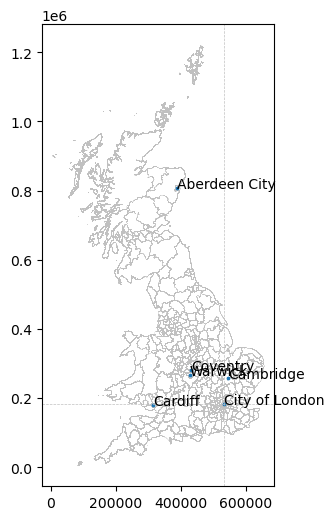

In [11]:
def plot_map_on_ax(ax, sf, s=0.1):
    apShapes = sf.shapes()
    points = []
    for shape in apShapes:
        points += list(shape.points)
    points = np.array(points)
    ax.scatter(points[::10,0], points[::10,1], s=s, linewidths=0, color='silver')
    ax.axvline(532382, color='silver', ls='--', lw=0.5)
    ax.axhline(181358, color='silver', ls='--', lw=0.5)
    ax.autoscale_view()

fig, ax = plt.subplots(1,1, figsize=(3, 6))
plot_map_on_ax(ax,sf)

ax.scatter(
    df_geo_sub_checkmap['bng_e'],
    df_geo_sub_checkmap['bng_n'],
    s=3
)

for _, row in df_geo_sub_checkmap.iterrows():
    ax.text(
        x=row['bng_e'],
        y=row['bng_n'],
        s=row['lau118nm']
    )

## Plot model output on map

In [12]:
from dataset_PropertyPrice import DataModuleHousePrice, DatasetHousePrice
import torch
import gc
device = 'cpu'


ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=0.5, 
    t_resol=t_resol,
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False,
)
df_obs = ds._get_df_Xy_trans_obs()


def pred_from_SurvSurf(run_id, proj_name, ds_df_dir, split='val', feat_grad=False):
    import wandb
    from model_factory_survsurf import LitModelSurvSurf
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelSurvSurf.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleHousePrice(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=True, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4,
        n_steps=n_g_steps,
        equal_steps=equal_steps
    )
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()


    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        xs_all = []
        if feat_grad:
            grads_all = []
        # with torch.no_grad():
        for batch_, (subj, xs, gs, ts, ys, weight, _) in enumerate(dataloader):
            xs, gs, ts, ys = xs.to(device), gs.to(device), ts.to(device), ys.to(device)
            if feat_grad:
                xs.requires_grad = True
                out = model_loaded_core(ts, gs, xs)
            else:
                with torch.no_grad():
                    out = model_loaded_core(ts, gs, xs)
            if feat_grad:
                grads = torch.autograd.grad(
                    outputs=out,
                    inputs=xs,
                    grad_outputs=torch.ones_like(out),
                    create_graph=True,
                    retain_graph=True
                )[0]
                grads_all += list(grads.cpu().detach().numpy())
            subjs += list(subj)
            g += list(datamodule.g_max*gs.cpu().detach().numpy()[:,0])
            t += list(ts.cpu().detach().numpy()[:,0])
            truth += list(ys.cpu().detach().numpy()[:,0])
            pred += list(out.cpu().detach().numpy()[:,0])
            xs_all += list(xs.cpu().detach().numpy())

        pred = np.array(pred)
        truth = np.array(truth)
        
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth

        
        cols = np.array(sorted([i for i in df_obs.columns if i.startswith('feat')]))
        df_xs_all = pd.DataFrame(xs_all, columns=cols)
        df_val_results = df_val_results.join(df_xs_all)
        
        if feat_grad:
            
            cols = np.array(sorted(['grad_' + i for i in df_obs.columns if i.startswith('feat')]))
            grads_all = pd.DataFrame(grads_all, columns=cols)
            df_val_results = df_val_results.join(grads_all)
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
        df_val_results = df_val_results.sort_values(['subj', 't', 'g'])
    return out_dfs, model_loaded_core.__class__.__name__


In [13]:
run_id = '9gtyn4p7'
out_model_default, model_name = pred_from_SurvSurf(run_id=run_id, proj_name=proj_name, ds_df_dir=ds_df_dir, split=split)

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [14]:
df_traj = pd.read_csv('./dataset_split/house_price_traj__df_state_history_sampled_max_test.csv', index_col=0)
df_traj.head()

,traj_id,t,g_max_by_time
6606,E06000001SemiNew,0.0,0.000000
6607,E06000001SemiNew,1.0,0.014897
6608,E06000001SemiNew,2.0,0.014897
6609,E06000001SemiNew,3.0,0.022435
6610,E06000001SemiNew,4.0,0.074765


In [15]:
df_to_plot = out_model_default['true_prob'].copy()

df_to_plot['loc_code'] = [i[:9] for i in df_to_plot['subj']]
df_to_plot['loc_e_m'] = df_to_plot['loc_code'].map(df_geo['bng_e'])
df_to_plot['loc_n_m'] = df_to_plot['loc_code'].map(df_geo['bng_n'])
df_to_plot['PropertyType'] = df_to_plot['subj'].apply(lambda x: x[9:])
df_to_plot = df_to_plot.merge(df_traj, left_on=['subj','t'], right_on=['traj_id','t'])
df_to_plot = df_to_plot.rename(columns={'g_max_by_time':'max % increase by time'})
df_to_plot_sub = df_to_plot.loc[
    (df_to_plot['g'] == 0.01) & (df_to_plot['t'] == 1),:
]
df_to_plot_sub['loc_code'].value_counts().value_counts()

count
1    106
2     34
3      7
Name: count, dtype: int64

In [16]:
pd.crosstab(
    df_to_plot['g'],
    df_to_plot['t']
)

t,1.0,2.0,3.0,4.0,5.0,6.0,7.0
g,,,,,,,
0.01,195,187,188,187,186,172,105
0.02,195,187,188,187,186,172,105
0.03,195,187,188,187,186,172,105
0.04,195,187,188,187,186,172,105
0.05,195,187,188,187,186,172,105
...,...,...,...,...,...,...,...
0.96,195,187,188,187,186,172,105
0.97,195,187,188,187,186,172,105
0.98,195,187,188,187,186,172,105


In [17]:
df_to_plot_sub['PropertyType'].value_counts()

PropertyType
SemiExisting        30
TerracedNew         29
TerracedExisting    29
DetachedNew         25
SemiNew             23
DetachedExisting    22
FlatExisting        19
FlatNew             18
Name: count, dtype: int64

In [18]:
df_to_plot.loc[
    (df_to_plot['g'] == 0.1) & (df_to_plot['t'] == 1),:
]


,subj,g,t,pred,truth,feat__deprived_0_dim,feat__deprived_1_dim,feat__deprived_2_dim,feat__deprived_3_dim,feat__deprived_4_dim,...,feat__tenure__owned_with_mortgage_or_shared_ownership,feat__tenure__private_rent_commercial,feat__tenure__private_rent_other,feat__tenure__rented_from_local_auth,loc_code,loc_e_m,loc_n_m,PropertyType,traj_id,max % increase by time
36,E06000001SemiNew,0.1,1.0,0.148908,0.0,-1.297894,-0.505535,1.609987,1.604944,0.088157,...,0.330002,-0.795879,-0.684989,0.072418,E06000001,447157,531476,SemiNew,E06000001SemiNew,0.014897
463,E06000002DetachedExisting,0.1,1.0,0.006685,0.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,0.711814,-0.749763,-0.221492,-0.393374,E06000002,451141,516887,DetachedExisting,E06000002DetachedExisting,0.043635
1154,E06000002DetachedNew,0.1,1.0,0.135853,0.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,0.711814,-0.749763,-0.221492,-0.393374,E06000002,451141,516887,DetachedNew,E06000002DetachedNew,0.000000
1727,E06000002TerracedNew,0.1,1.0,0.234339,0.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,-0.380191,0.686823,0.237783,0.315370,E06000002,451141,516887,TerracedNew,E06000002TerracedNew,0.062381
2054,E06000003SemiNew,0.1,1.0,0.176233,0.0,-0.931747,-0.020892,1.187648,0.790108,0.128710,...,0.392190,-0.854352,-0.661641,0.005732,E06000003,464359,519597,SemiNew,E06000003SemiNew,0.057778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118463,W06000015SemiExisting,0.1,1.0,0.162008,0.0,-0.179957,-0.722750,0.111063,0.867854,1.011119,...,0.577731,-0.720567,-0.575085,0.086318,W06000015,315270,178887,SemiExisting,W06000015SemiExisting,0.055140
119163,W06000019TerracedExisting,0.1,1.0,0.079813,0.0,-2.217026,-1.352701,2.799559,2.966787,0.841435,...,-0.048179,-0.181432,-0.489915,-0.161305,W06000019,318236,206771,TerracedExisting,W06000019TerracedExisting,0.048328
119863,W06000021TerracedExisting,0.1,1.0,0.078583,0.0,0.416219,-0.140622,-0.297628,-0.598682,-0.750333,...,0.275338,-0.308881,-0.530071,-0.347343,W06000021,337812,209231,TerracedExisting,W06000021TerracedExisting,0.013127
120554,W06000022SemiNew,0.1,1.0,0.223671,0.0,-0.770613,-0.496848,1.009031,0.944718,0.577254,...,0.617532,-0.758461,-0.714356,-0.266285,W06000022,337897,187433,SemiNew,W06000022SemiNew,0.015507


In [19]:
df_to_plot['max % increase by time'].isna().value_counts()

max % increase by time
False    122000
Name: count, dtype: int64

In [20]:
df_to_plot_sub

,subj,g,t,pred,truth,feat__deprived_0_dim,feat__deprived_1_dim,feat__deprived_2_dim,feat__deprived_3_dim,feat__deprived_4_dim,...,feat__tenure__owned_with_mortgage_or_shared_ownership,feat__tenure__private_rent_commercial,feat__tenure__private_rent_other,feat__tenure__rented_from_local_auth,loc_code,loc_e_m,loc_n_m,PropertyType,traj_id,max % increase by time
0,E06000001SemiNew,0.01,1.0,0.339603,1.0,-1.297894,-0.505535,1.609987,1.604944,0.088157,...,0.330002,-0.795879,-0.684989,0.072418,E06000001,447157,531476,SemiNew,E06000001SemiNew,0.014897
400,E06000002DetachedExisting,0.01,1.0,0.056833,1.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,0.711814,-0.749763,-0.221492,-0.393374,E06000002,451141,516887,DetachedExisting,E06000002DetachedExisting,0.043635
1100,E06000002DetachedNew,0.01,1.0,0.309793,0.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,0.711814,-0.749763,-0.221492,-0.393374,E06000002,451141,516887,DetachedNew,E06000002DetachedNew,0.000000
1700,E06000002TerracedNew,0.01,1.0,0.432866,1.0,-1.458634,0.028154,1.425301,1.982345,0.715353,...,-0.380191,0.686823,0.237783,0.315370,E06000002,451141,516887,TerracedNew,E06000002TerracedNew,0.062381
2000,E06000003SemiNew,0.01,1.0,0.383535,1.0,-0.931747,-0.020892,1.187648,0.790108,0.128710,...,0.392190,-0.854352,-0.661641,0.005732,E06000003,464359,519597,SemiNew,E06000003SemiNew,0.057778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118400,W06000015SemiExisting,0.01,1.0,0.848949,1.0,-0.179957,-0.722750,0.111063,0.867854,1.011119,...,0.577731,-0.720567,-0.575085,0.086318,W06000015,315270,178887,SemiExisting,W06000015SemiExisting,0.055140
119100,W06000019TerracedExisting,0.01,1.0,0.560118,1.0,-2.217026,-1.352701,2.799559,2.966787,0.841435,...,-0.048179,-0.181432,-0.489915,-0.161305,W06000019,318236,206771,TerracedExisting,W06000019TerracedExisting,0.048328
119800,W06000021TerracedExisting,0.01,1.0,0.523452,1.0,0.416219,-0.140622,-0.297628,-0.598682,-0.750333,...,0.275338,-0.308881,-0.530071,-0.347343,W06000021,337812,209231,TerracedExisting,W06000021TerracedExisting,0.013127
120500,W06000022SemiNew,0.01,1.0,0.522705,1.0,-0.770613,-0.496848,1.009031,0.944718,0.577254,...,0.617532,-0.758461,-0.714356,-0.266285,W06000022,337897,187433,SemiNew,W06000022SemiNew,0.015507


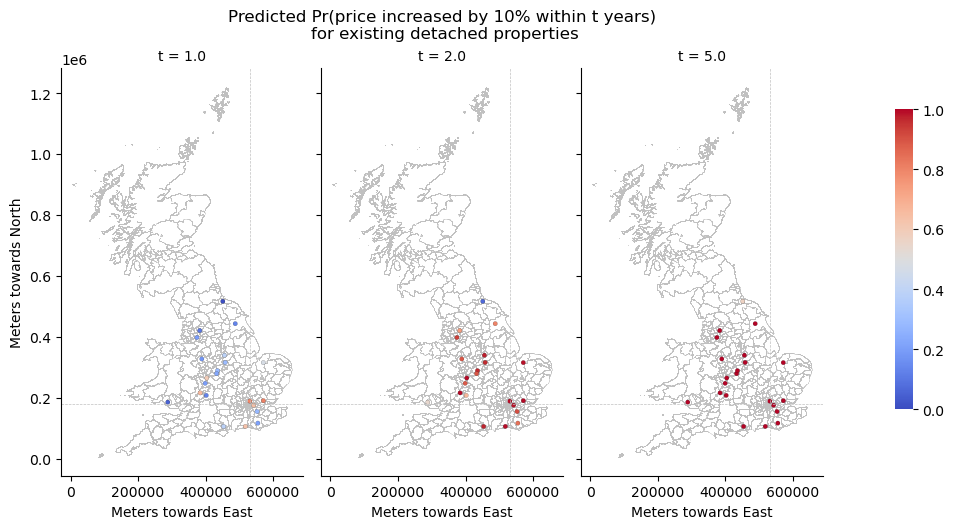

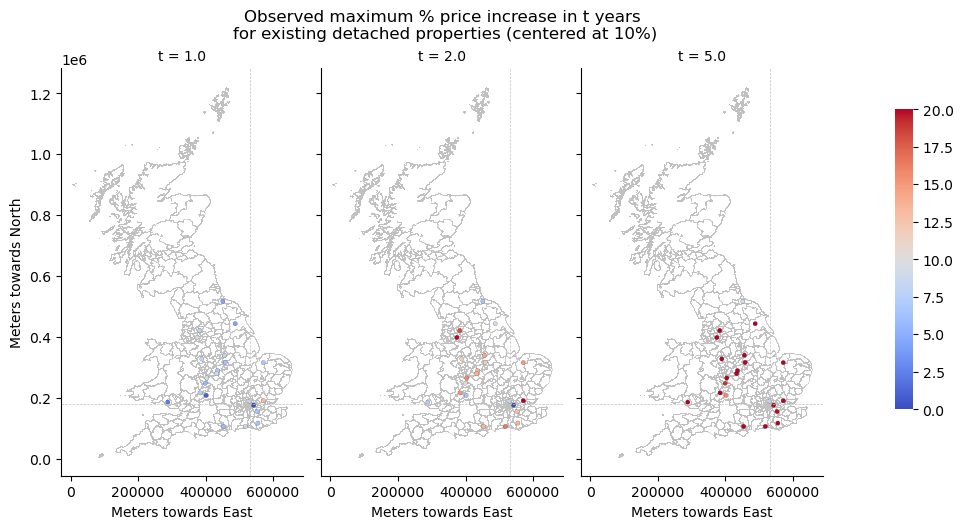

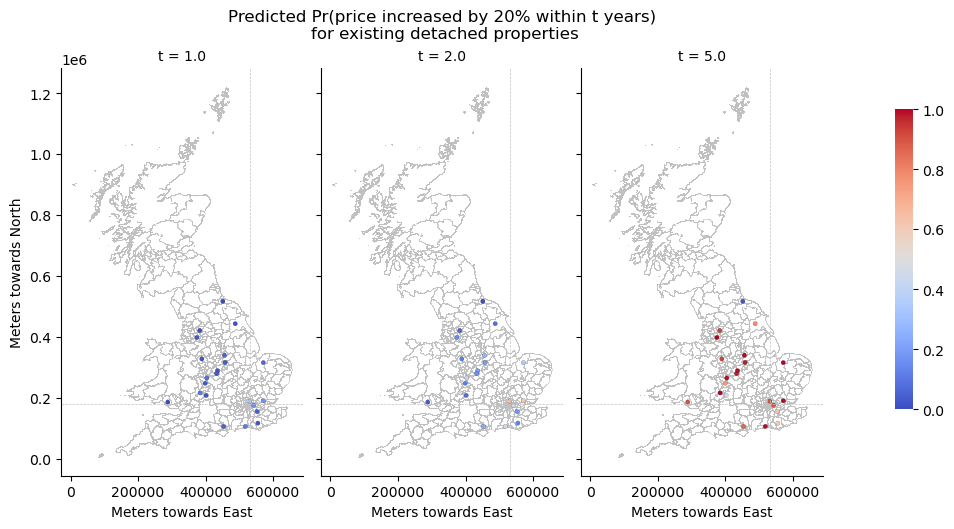

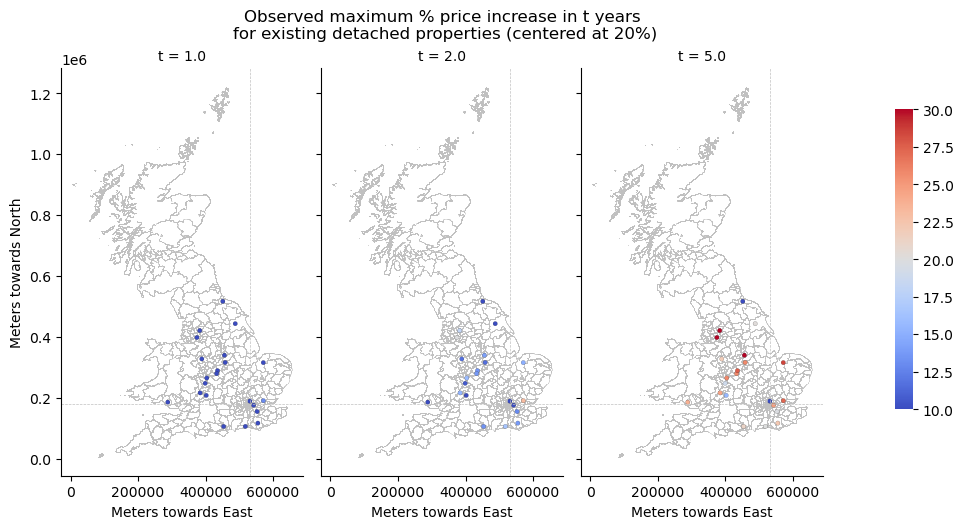

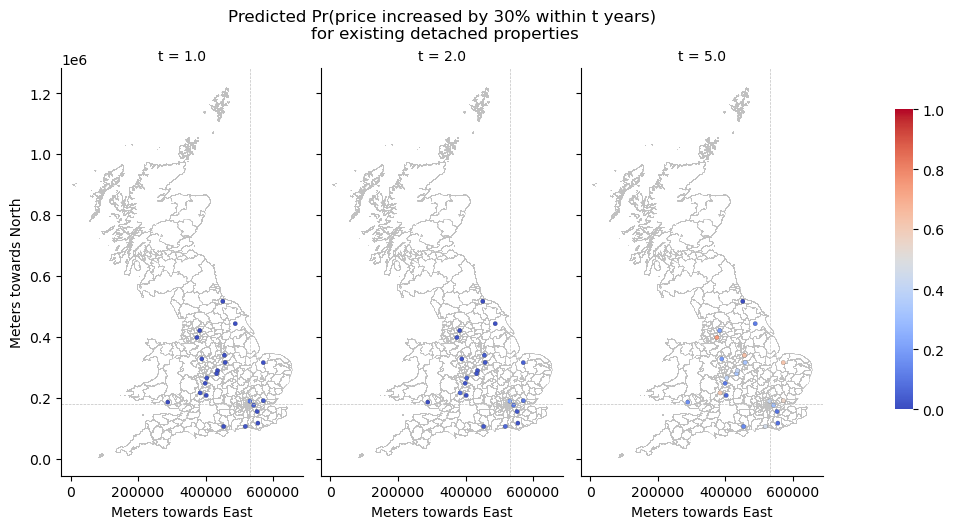

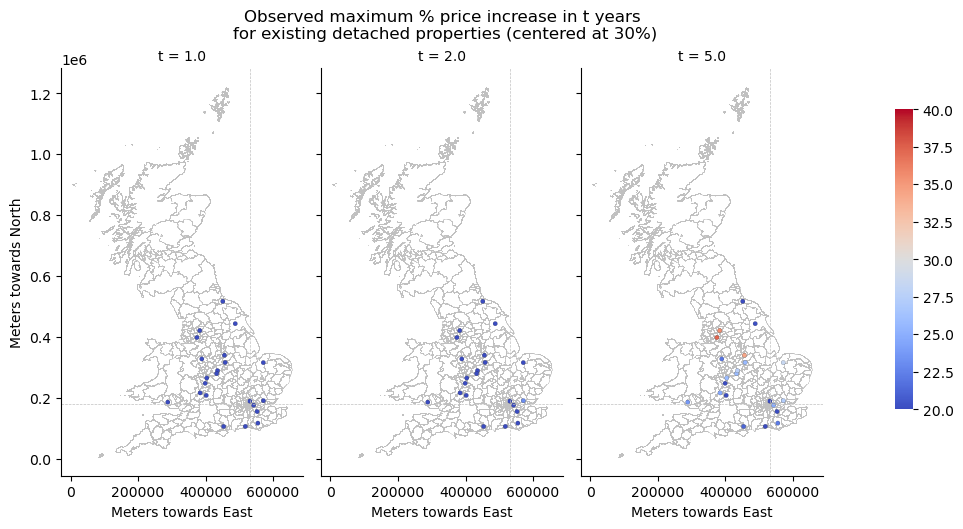

In [21]:
def facet_scatter(x, y, c, **kwargs):
    """Draw scatterplot with point colors from a faceted DataFrame columns."""
    kwargs.pop("color")
    plt.scatter(x, y, c=c, **kwargs)

for grp, df_to_plot_sub in df_to_plot.groupby('PropertyType'):
    for g in [0.1, 0.2, 0.3]:
        for col in ['Prediction','max % increase by time']:
            df = df_to_plot_sub.loc[
                (df_to_plot_sub['g'] == g) & (df_to_plot_sub['t'].isin([1,2,5])),:
            ].rename(columns={'pred':'Prediction'}).sort_values('t')
            if col == 'Prediction':
                hue_norm=(0., 1.)
                filename_tag = 'pred'
            else:
                hue_norm=((g-0.1)*100, (g+0.1)*100)
                df[col] = df[col]*100
                filename_tag = 'obs'
            canvas = sns.FacetGrid(
                data=df, 
                col="t", 
                # palette='coolwarm',
                # hue=col,
                sharex=True, 
                sharey=True, 
                height=5, 
                aspect=3/5,
            )
            for ax, in zip(canvas.axes_dict.values()):
                plot_map_on_ax(ax,sf, s=0.1)
            canvas.map(
                facet_scatter,
                'loc_e_m',
                'loc_n_m',
                col,
                edgecolor='black',
                vmin=hue_norm[0],
                vmax=hue_norm[1],
                cmap='coolwarm',
                linewidth=0.1,
                s=10
            )
            for ax in canvas.axes_dict.values():
                ax.set(xlabel='Meters towards East', ylabel='Meters towards North')

            if 'New' in grp:
                prop_type = grp.split('New')[0]
                new_old = 'new'
            
            if 'Existing' in grp:
                prop_type = grp.split('Existing')[0]
                new_old = 'existing'
            
            if 'flat' not in prop_type:
                prop_type = prop_type + ' properties'
            str_prob = f'price increased by {int(g*100)}% within t years'
            if 'Prediction' not in col:
                canvas.figure.suptitle(f'Observed maximum % price increase in t years \nfor {new_old} {prop_type.lower()} (centered at {int(g*100)}%)', x=0.5, y=1.05)
            else:
                canvas.figure.suptitle(f'Predicted Pr({str_prob}) \nfor {new_old} {prop_type.lower()}', x=0.5, y=1.05)
            canvas.figure.subplots_adjust(right=.92)
            cax = canvas.figure.add_axes([1.0, .25, .02, .6])
            points = plt.scatter([], [], c=[], vmin=hue_norm[0], vmax=hue_norm[1], cmap='coolwarm')

            # Draw the colorbar
            cb = canvas.figure.colorbar(points, cax=cax)
            cb.outline.set_visible(False)

            canvas.savefig(os.path.join('./output_fig', f'property_price_{grp}_g{int(g*100)}_{filename_tag}.png'), dpi=600)
    break


## Plot feature Influence on map

In [22]:
df_DyDx_test = pd.read_csv(f'./out_temp/df_DyDx__{split}.csv', index_col=0)
cols = [i for i in df_DyDx_test.columns if i.startswith('DyDx')]
cols = df_DyDx_test[cols].abs().median().sort_values(ascending=False).index.values
df_DyDx_test['loc_code'] = [i[:9] for i in df_DyDx_test['subj']]
df_DyDx_test['loc_e_m'] = df_DyDx_test['loc_code'].map(df_geo['bng_e'])
df_DyDx_test['loc_n_m'] = df_DyDx_test['loc_code'].map(df_geo['bng_n'])

selector = (df_DyDx_test['g'] == 0.3) & (df_DyDx_test['t'] == 5)
df_DyDx_test_sub = df_DyDx_test.loc[selector,:].copy()
df_DyDx_test_sub

,subj,g,t,DyDx__feat__is_new_build,DyDx__feat__long,DyDx__feat__lat,DyDx__feat__frac_properties_n_beds__1,DyDx__feat__frac_properties_n_beds__2,DyDx__feat__frac_properties_n_beds__3,DyDx__feat__frac_properties_n_beds__4,...,DyDx__feat__soc_grade_AB,DyDx__feat__soc_grade_C1,DyDx__feat__soc_grade_C2,DyDx__feat__soc_grade_DE,DyDx__feat__prop_type_Detached,DyDx__feat__prop_type_SemiD,DyDx__feat__prop_type_Terraced,loc_code,loc_e_m,loc_n_m
207,E06000001SemiNew,0.3,5.0,0.082700,0.021417,-0.173702,-0.001879,-0.000760,0.004145,0.005410,...,0.092971,0.008821,0.020728,-0.010859,0.085950,-0.004369,0.036536,E06000001,447157,531476
907,E06000002DetachedExisting,0.3,5.0,0.070586,0.002497,-0.228548,-0.000196,0.000884,0.002413,0.000308,...,0.020409,0.000613,0.002090,0.000084,0.002189,0.001595,0.003498,E06000002,451141,516887
1607,E06000002DetachedNew,0.3,5.0,0.070586,0.025024,-0.059681,0.008124,0.009719,0.014724,0.002974,...,0.081450,0.004814,0.015246,-0.009102,0.034218,-0.002930,0.036789,E06000002,451141,516887
2307,E06000002TerracedNew,0.3,5.0,0.126244,0.032716,-0.081495,0.021321,0.016707,-0.006195,-0.001476,...,0.062295,-0.001416,0.022527,-0.013234,NaN,-0.012483,0.027758,E06000002,451141,516887
3007,E06000003SemiNew,0.3,5.0,0.087655,0.019096,-0.068978,-0.006339,-0.003885,0.014771,0.003183,...,0.068532,0.006356,0.013695,-0.011104,0.075679,-0.008366,0.031310,E06000003,464359,519597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136707,W06000019TerracedExisting,0.3,5.0,0.119797,0.117619,0.317675,0.111030,0.150445,0.141344,0.035132,...,0.146053,0.044778,0.166682,0.044168,0.475555,0.387411,0.306065,W06000019,318236,206771
137407,W06000021TerracedExisting,0.3,5.0,0.223135,0.142872,0.013648,-0.014307,0.049031,0.044609,0.009288,...,0.128919,0.167247,0.076785,0.033744,0.326765,0.183702,0.075685,W06000021,337812,209231
138107,W06000022SemiNew,0.3,5.0,-0.217354,0.130479,-0.116602,-0.008052,0.094121,0.098147,0.010349,...,0.241364,0.128032,0.169656,0.022974,0.370438,0.154216,0.286437,W06000022,337897,187433
138807,W06000024SemiNew,0.3,5.0,0.167496,0.112064,0.028937,-0.000648,0.077721,0.037513,0.017121,...,0.154873,0.097281,0.098225,0.021727,0.202648,0.096260,0.170572,W06000024,305916,206424


In [23]:
cols

array(['DyDx__feat__is_new_build',
       'DyDx__feat__ethn_Black;rlgn_Christian',
       'DyDx__feat__prop_type_Detached', 'DyDx__feat__econ_act_full_time',
       'DyDx__feat__econ_inact_long_term_health',
       'DyDx__feat__soc_grade_AB', 'DyDx__feat__ethn_Asian;rlgn_Muslim',
       'DyDx__feat__prop_type_Terraced', 'DyDx__feat__long',
       'DyDx__feat__ethn_OtherWhite;rlgn_None',
       'DyDx__feat__ethn_British;rlgn_Christian',
       'DyDx__feat__tenure__owned_with_mortgage_or_shared_ownership',
       'DyDx__feat__tenure__other_social_rent', 'DyDx__feat__lat',
       'DyDx__feat__tenure__owned_outright',
       'DyDx__feat__frac_properties_n_beds__2',
       'DyDx__feat__ethn_British;rlgn_None',
       'DyDx__feat__econ_inact_student', 'DyDx__feat__soc_grade_C2',
       'DyDx__feat__prop_type_SemiD', 'DyDx__feat__econ_act_self_emp',
       'DyDx__feat__tenure__private_rent_commercial',
       'DyDx__feat__frac_properties_n_beds__3',
       'DyDx__feat__ethn_Other;rlgn_Muslim'

/tmp/ipykernel_29362/3877675893.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1, figsize=(6, 8))


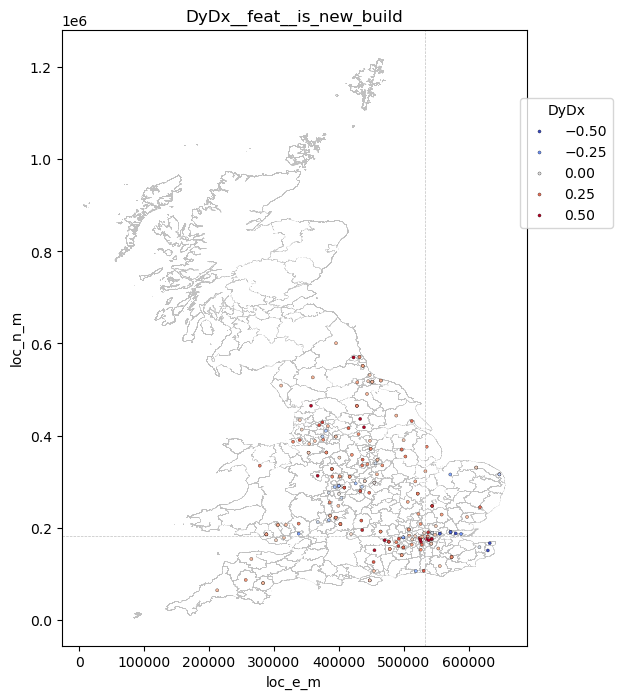

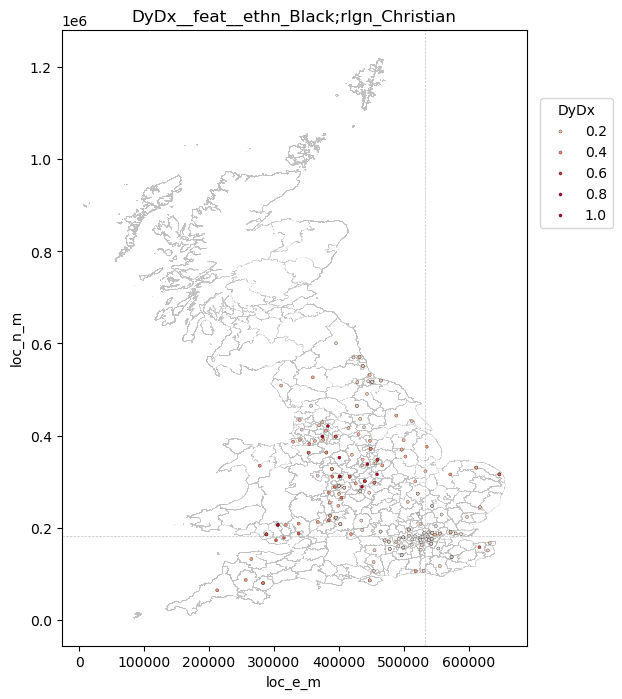

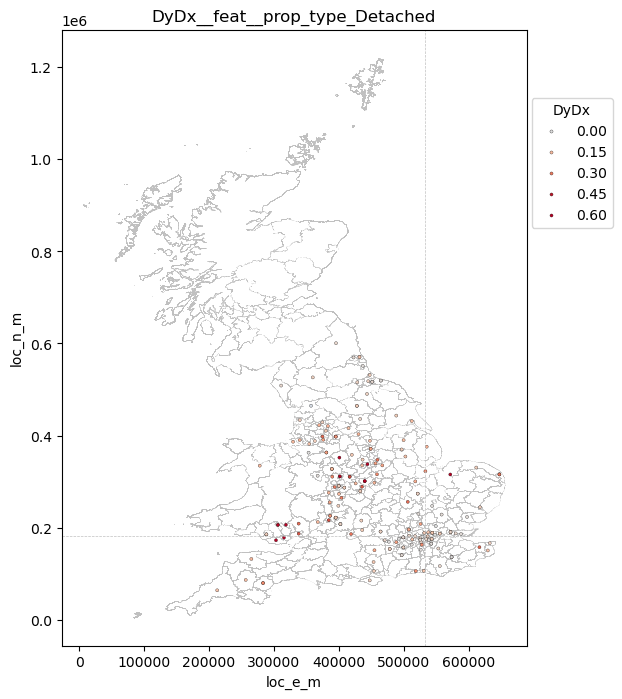

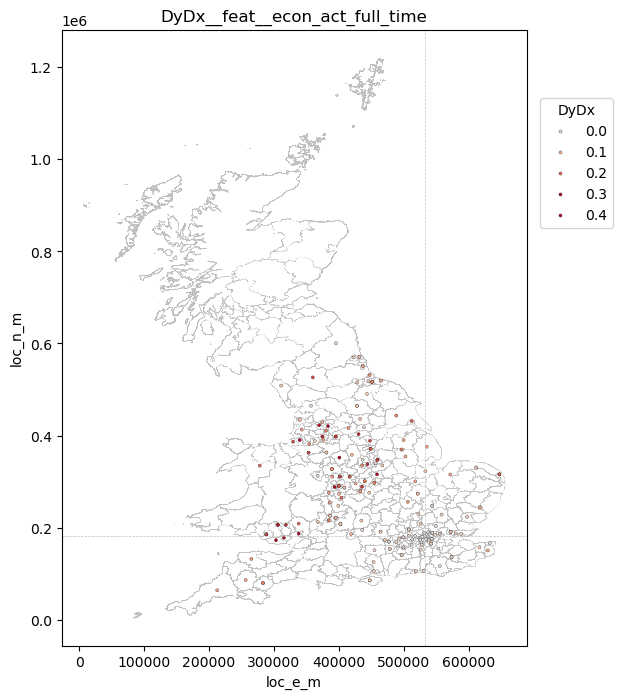

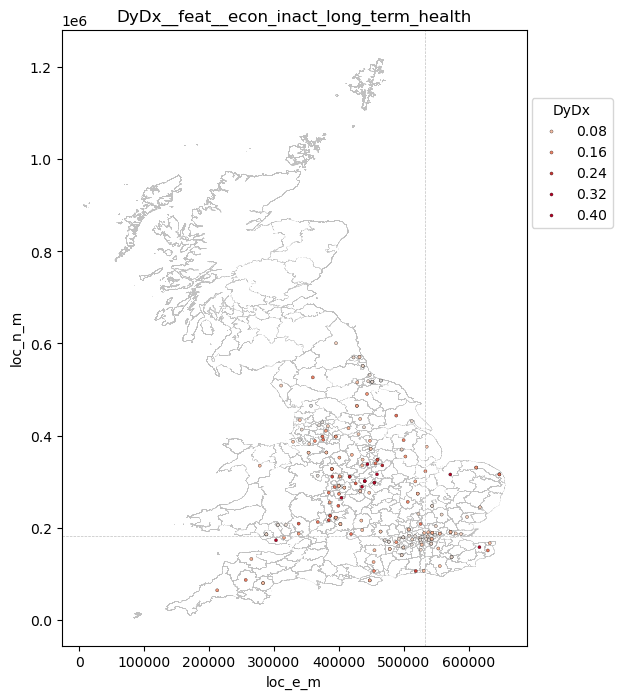

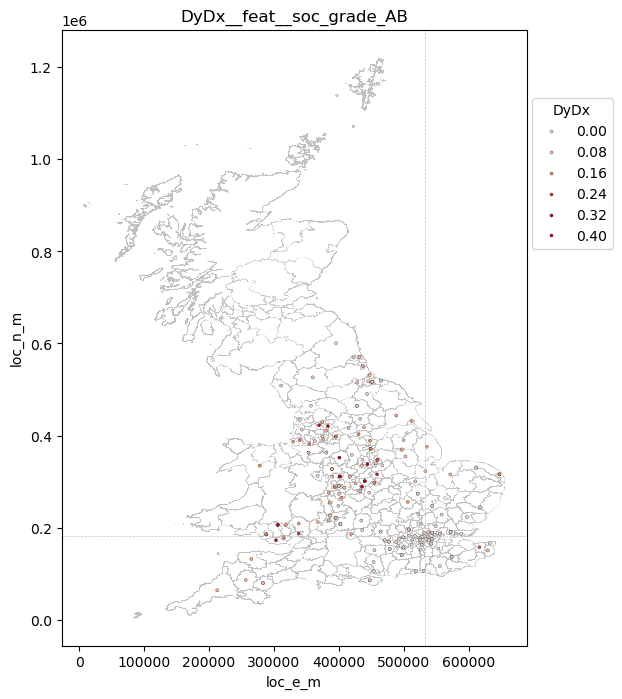

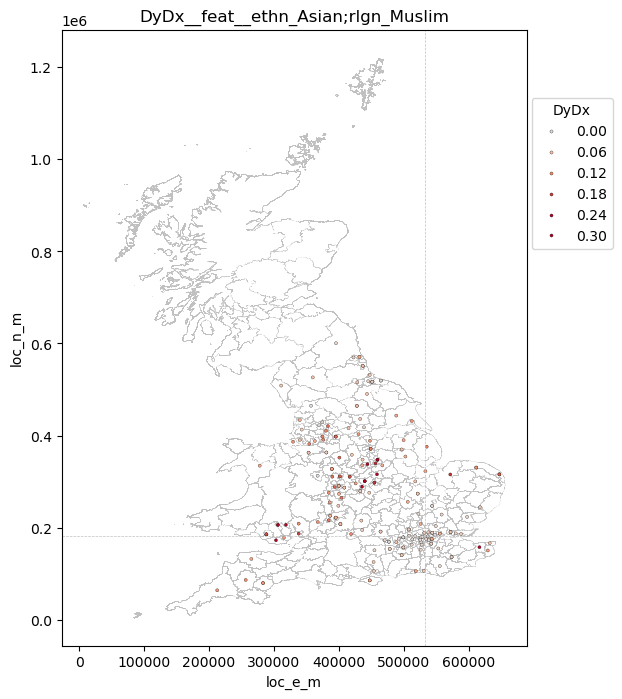

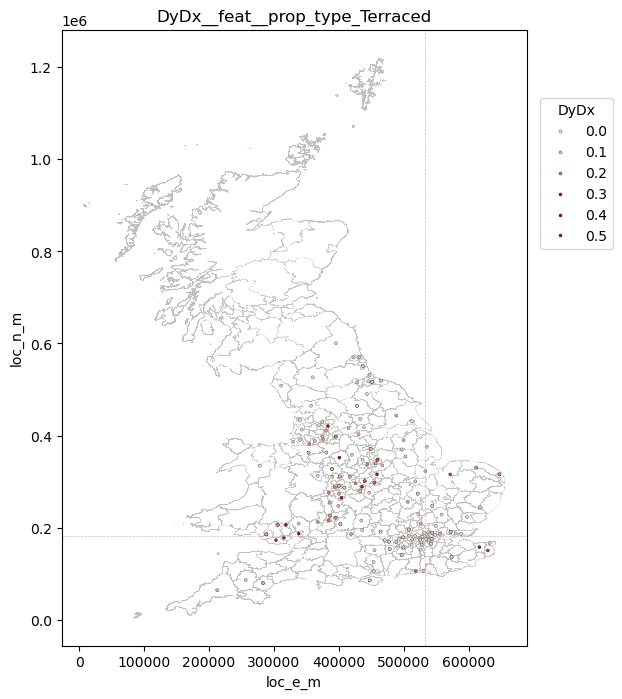

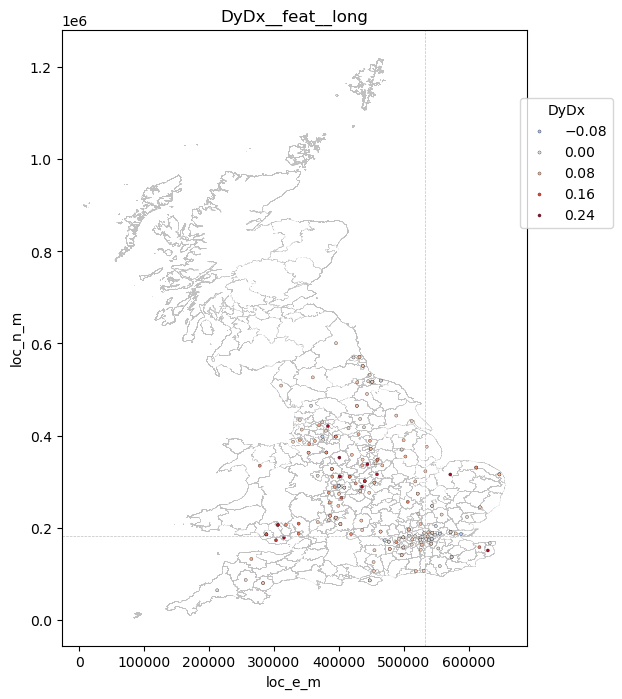

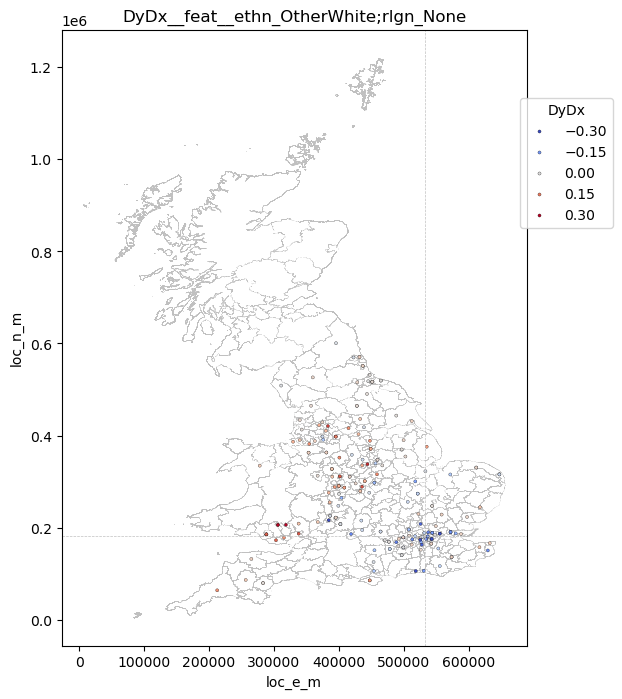

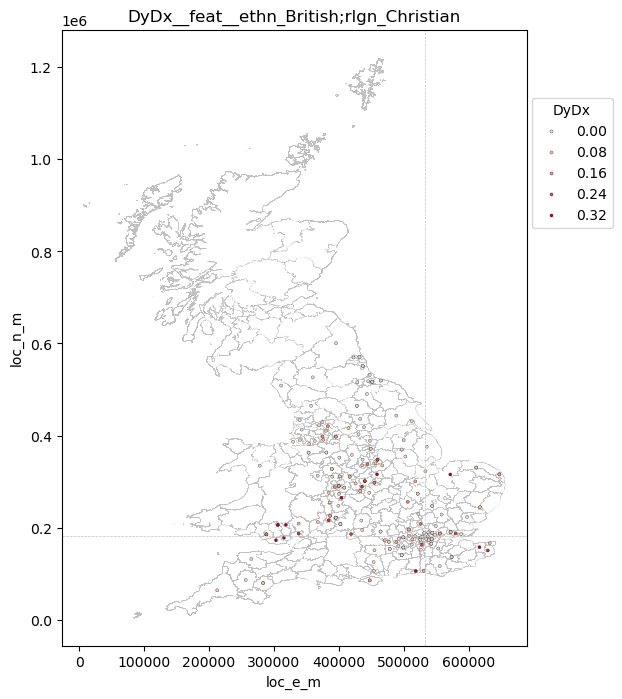

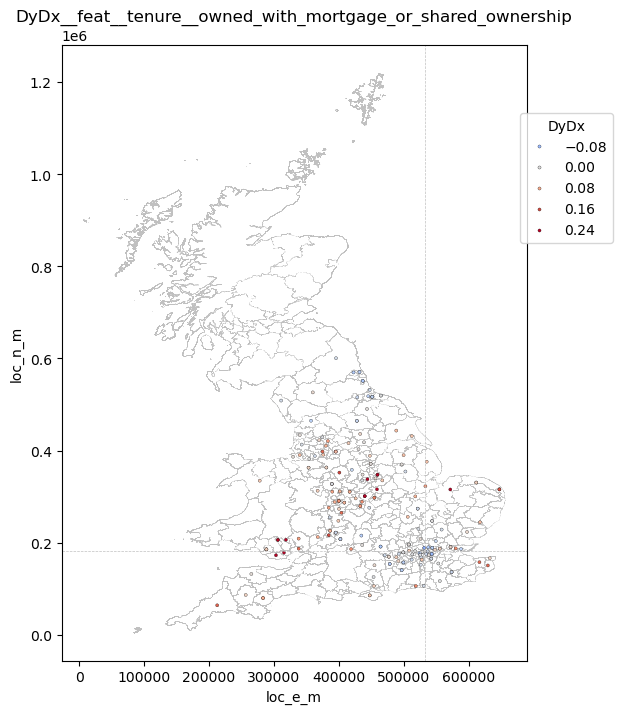

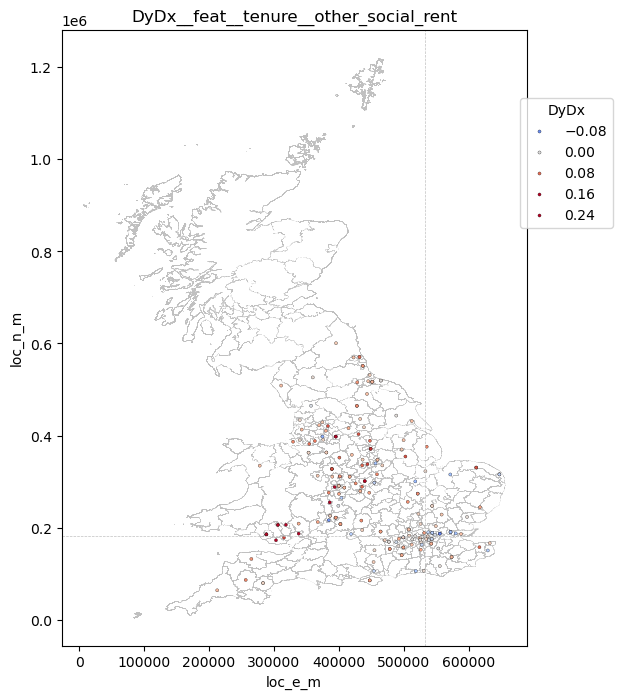

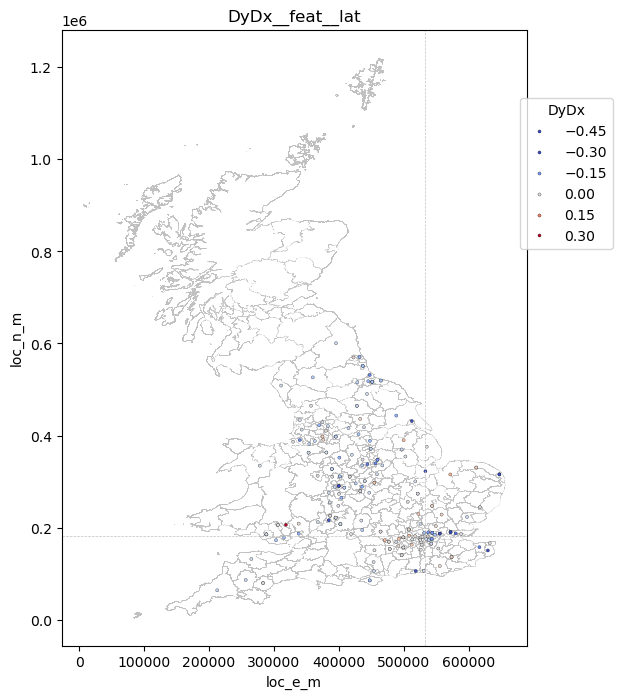

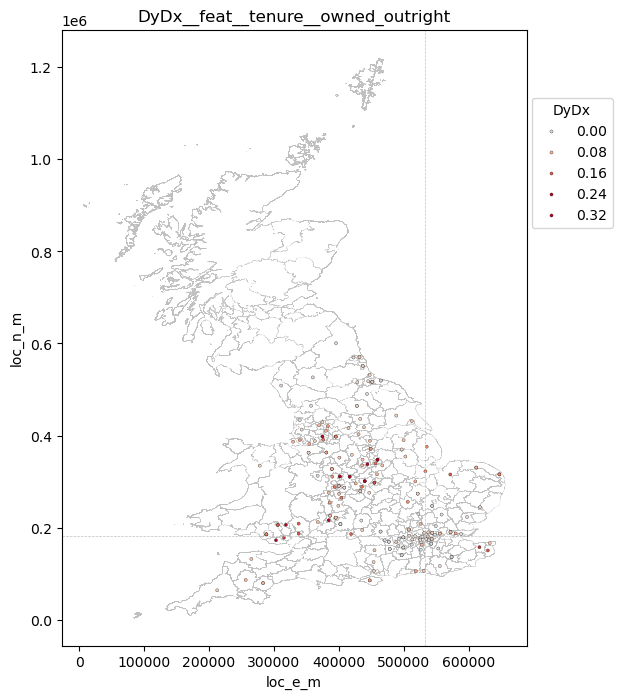

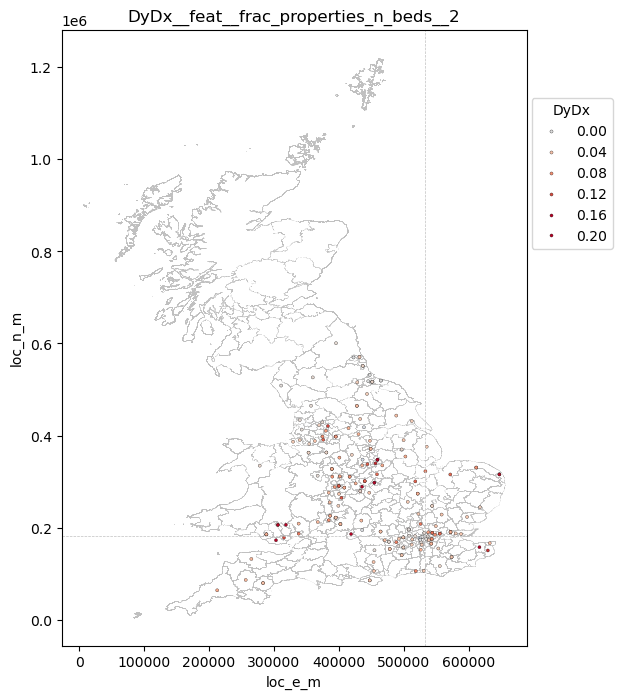

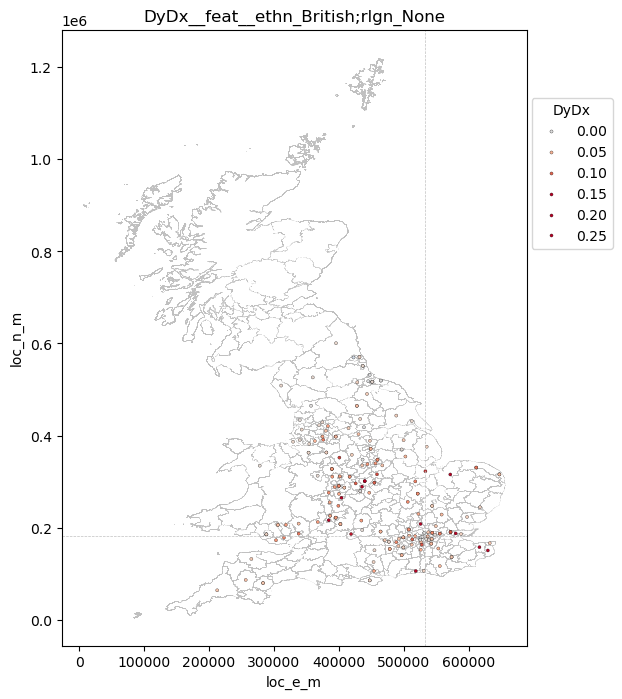

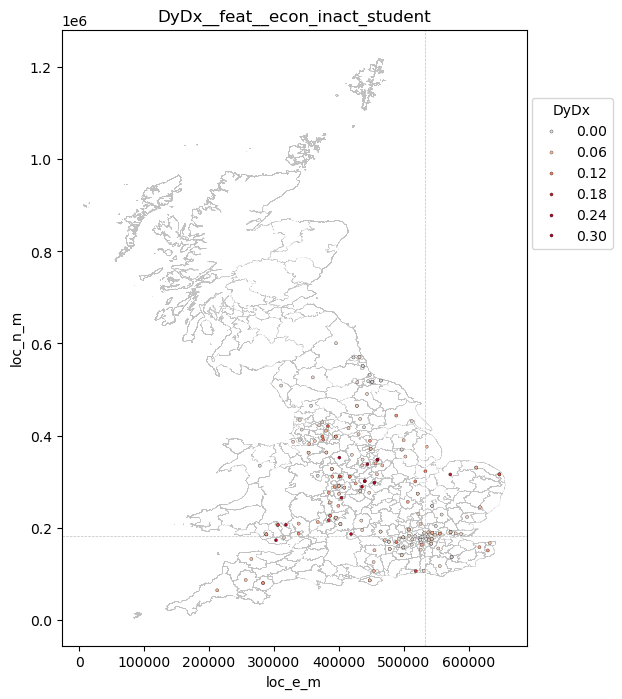

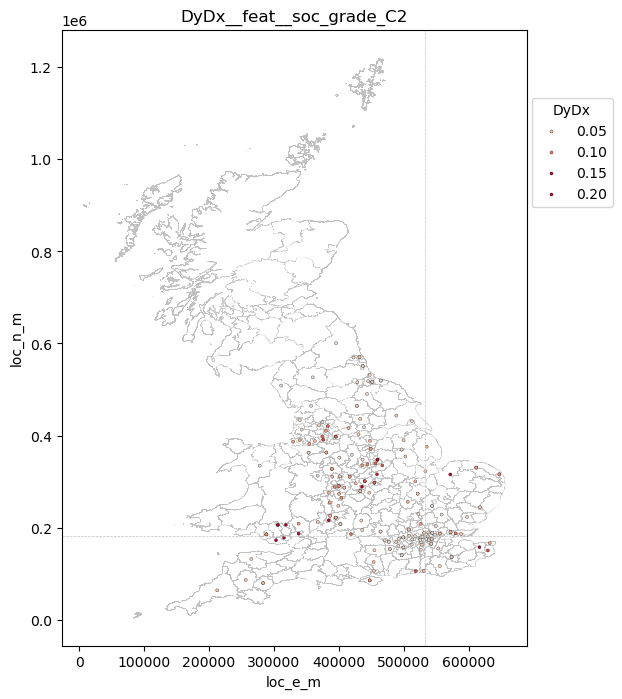

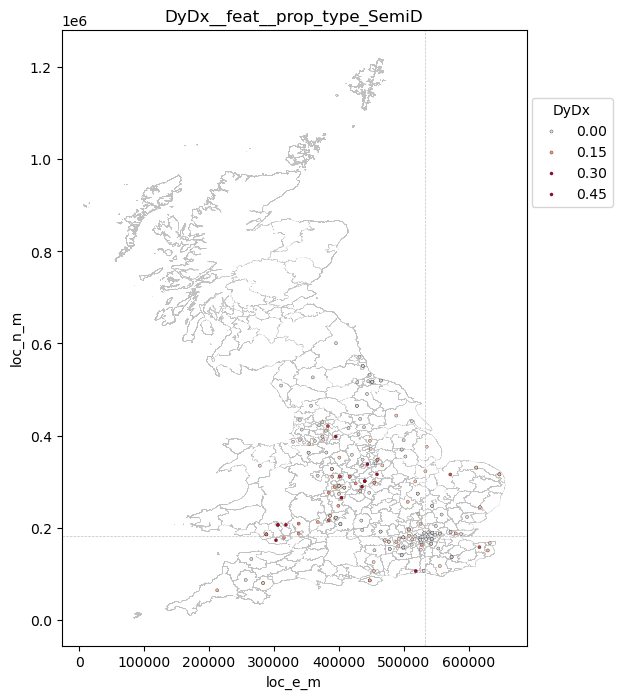

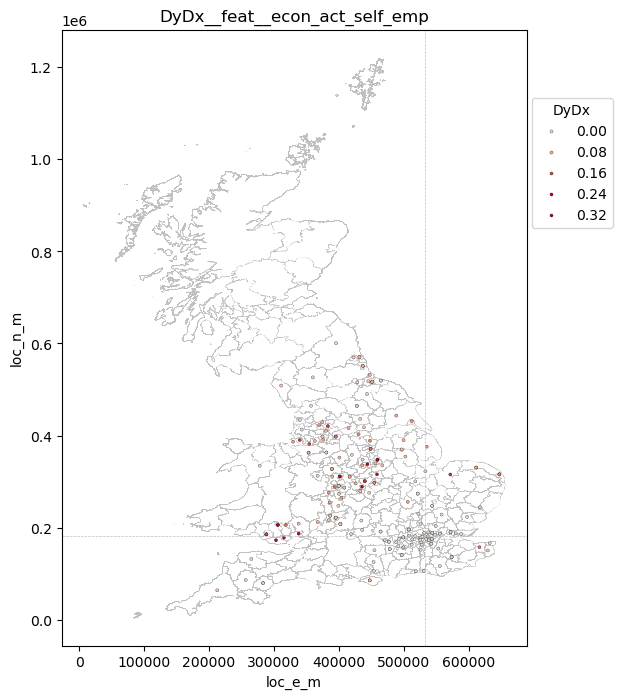

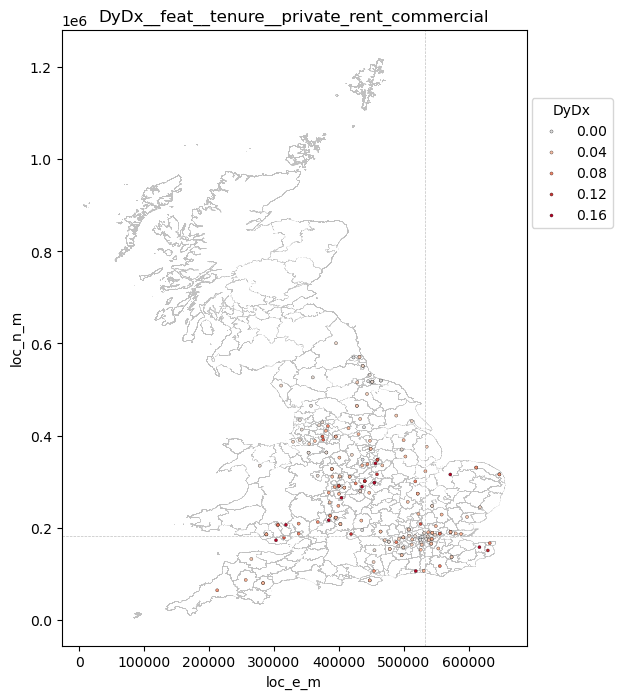

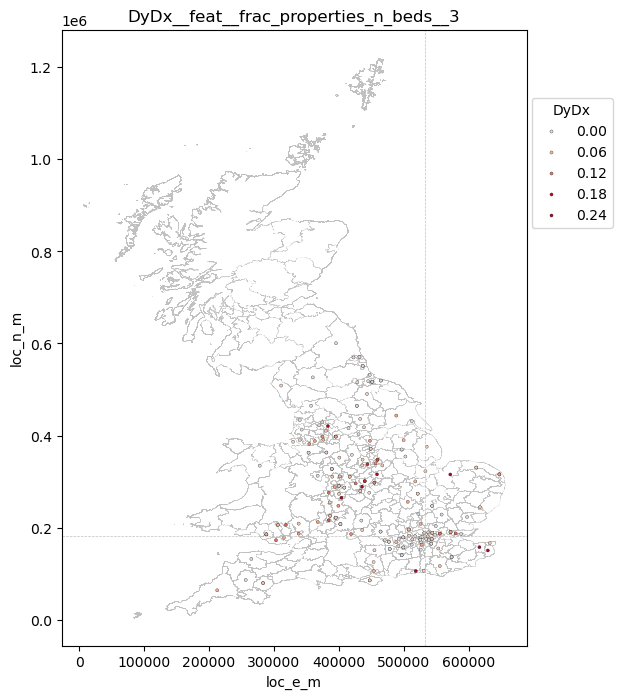

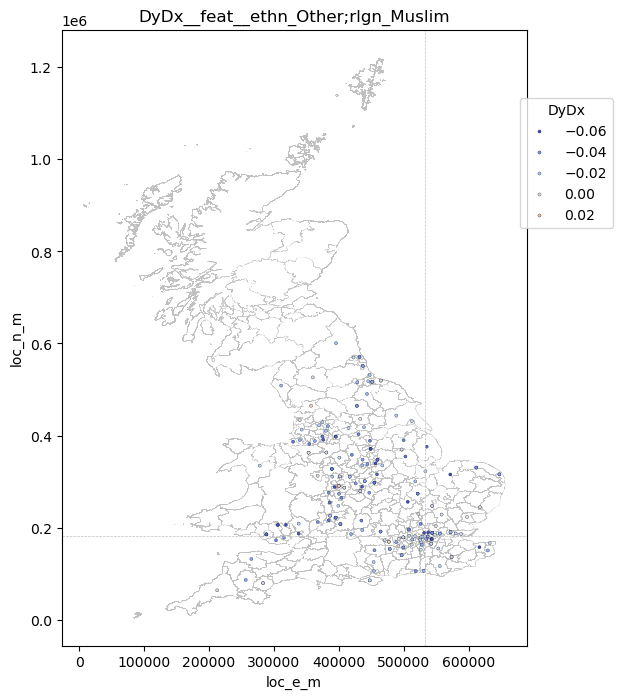

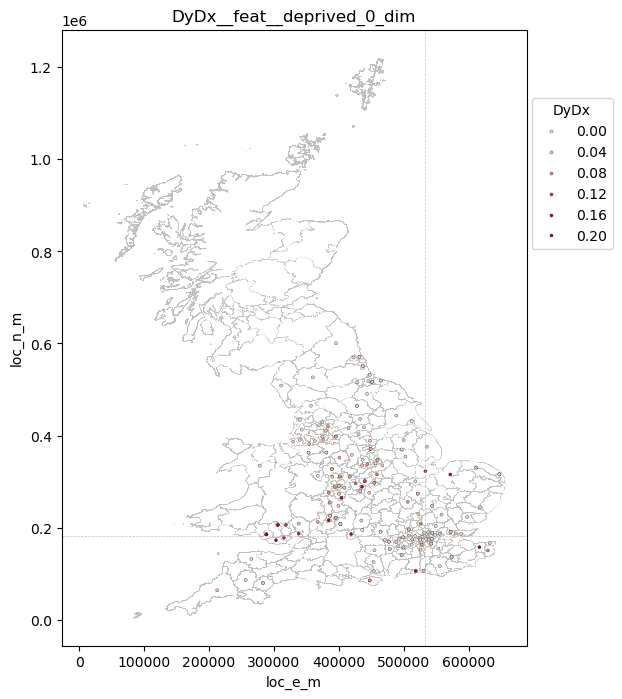

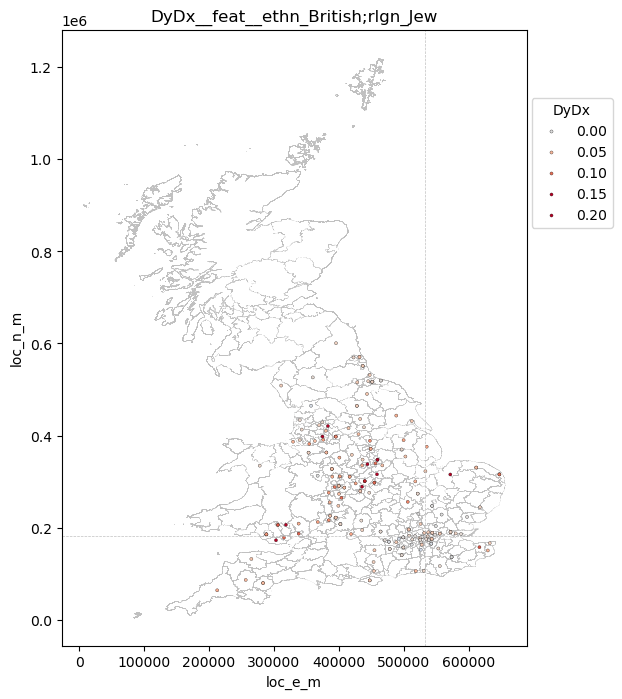

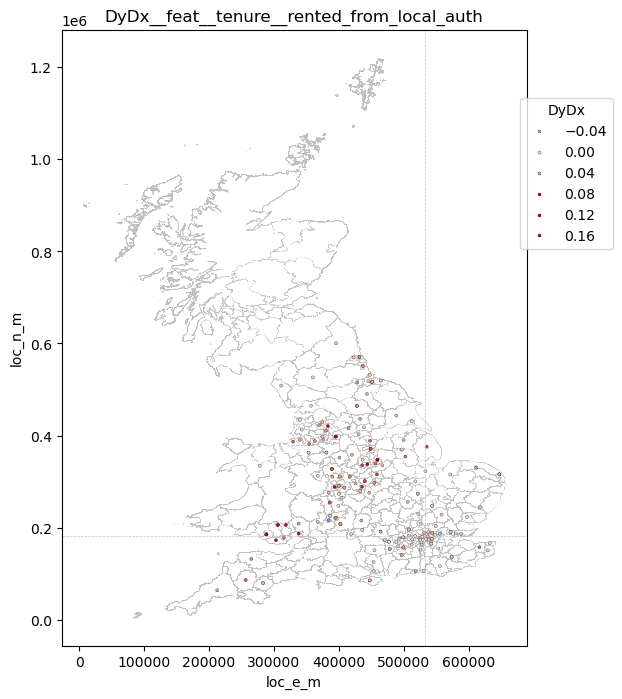

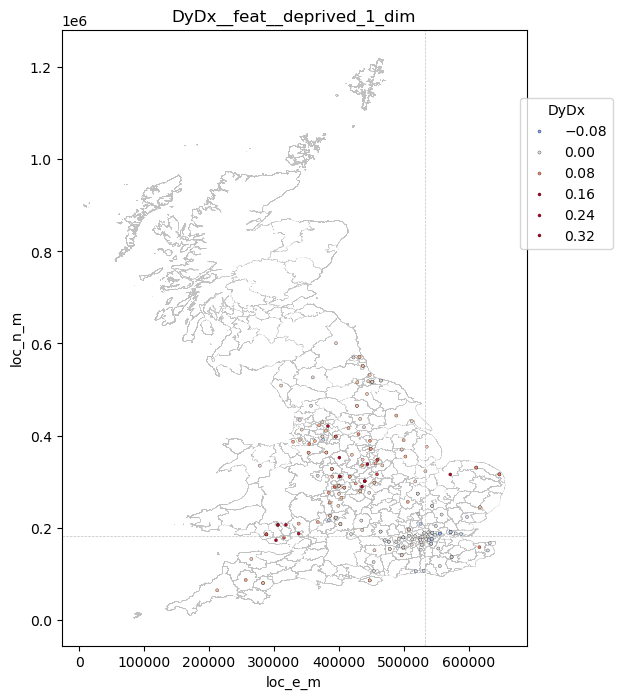

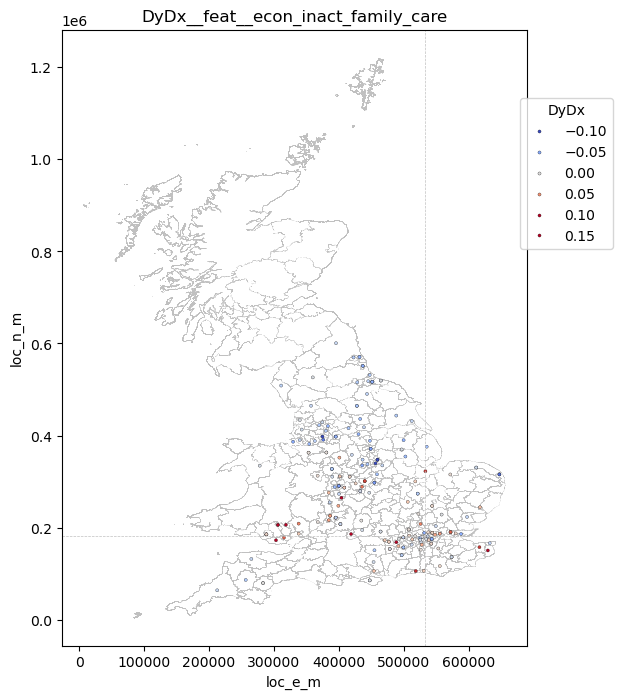

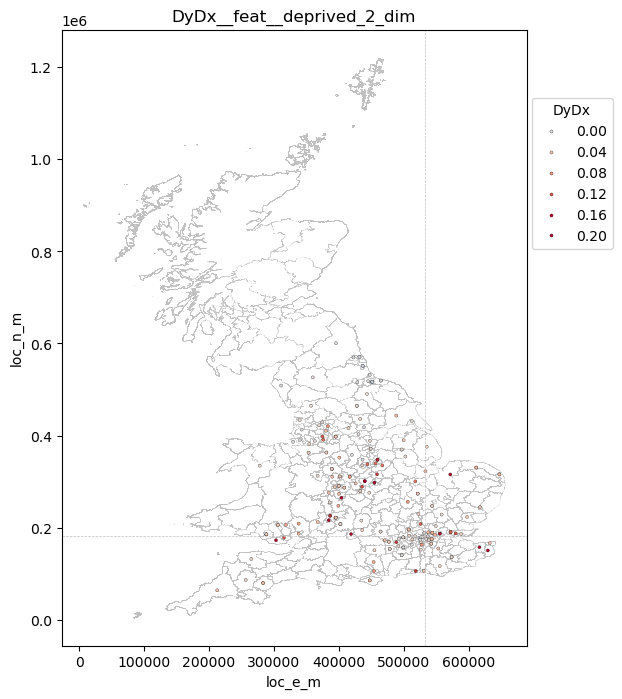

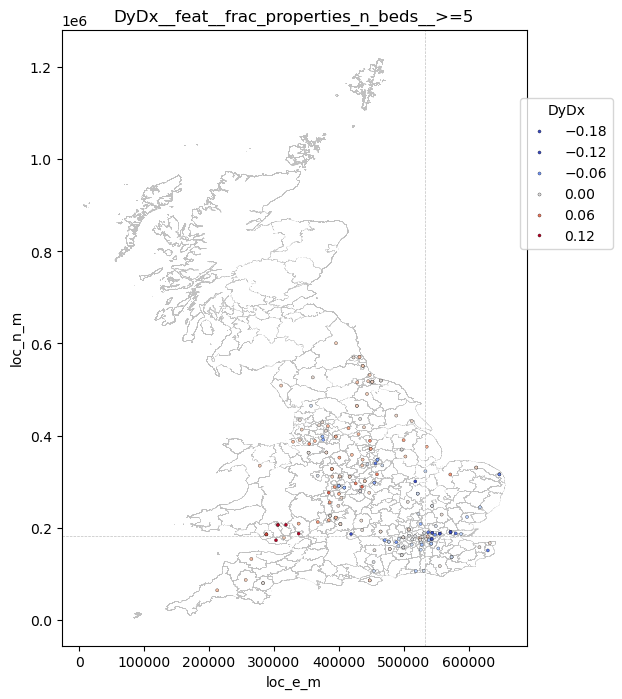

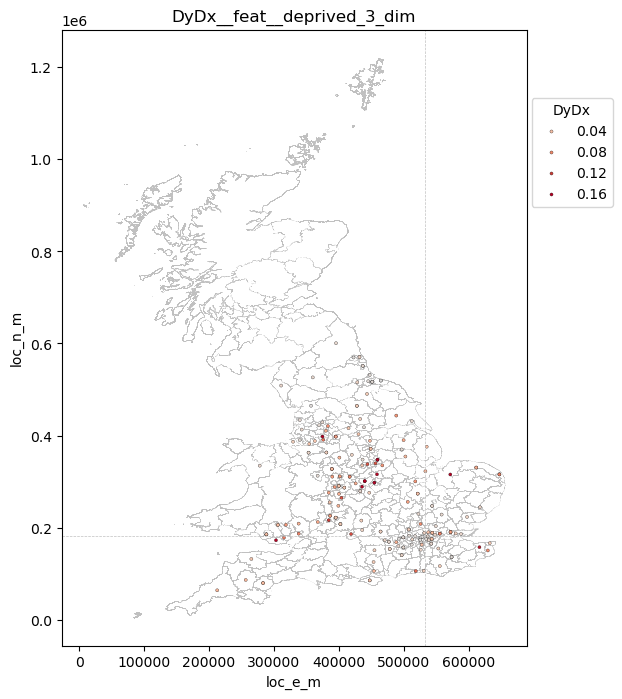

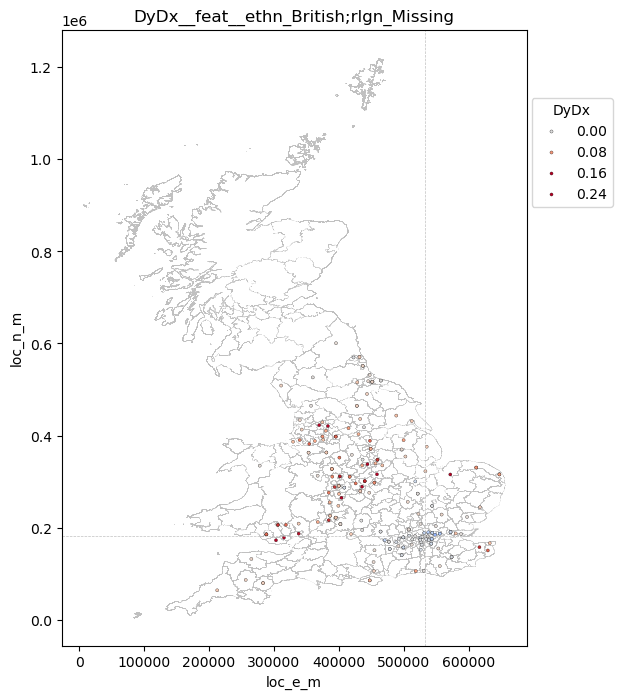

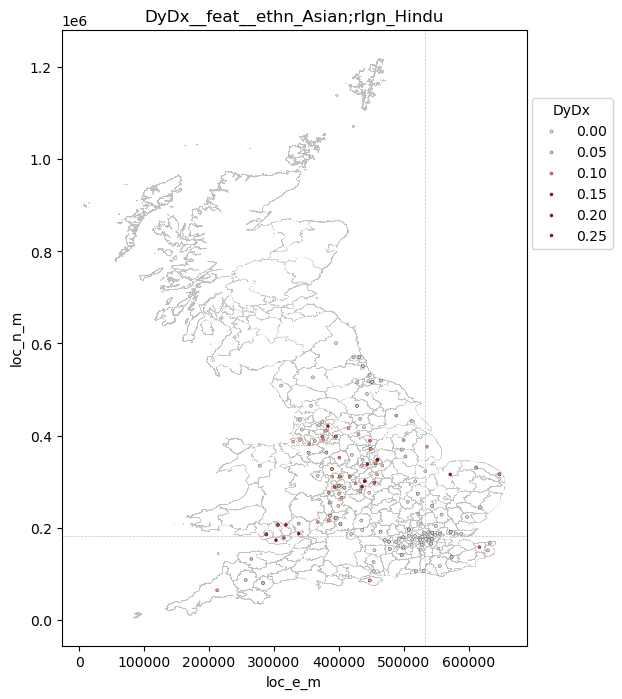

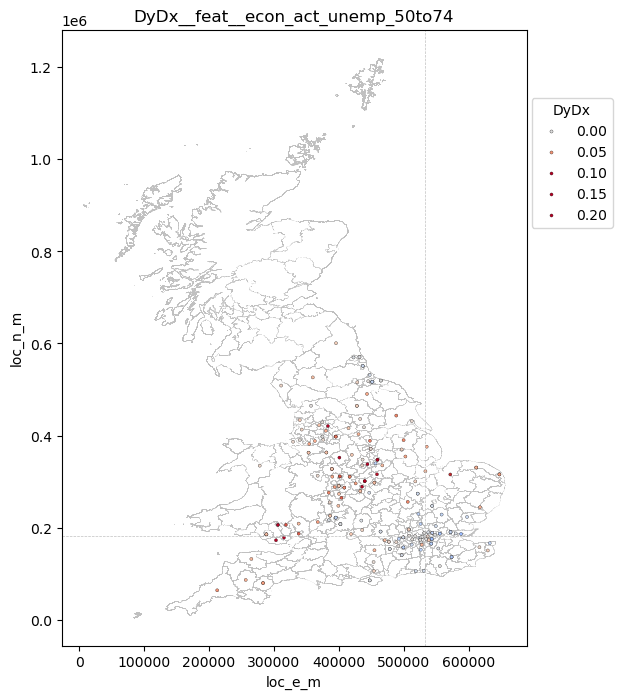

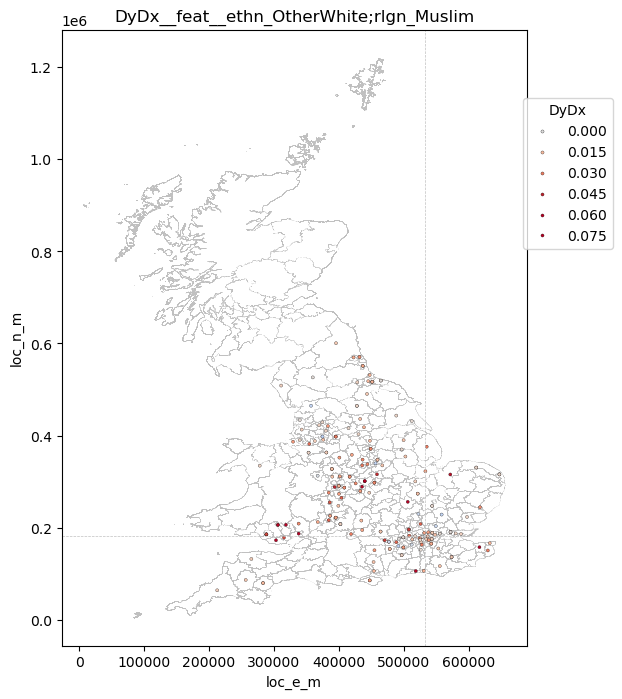

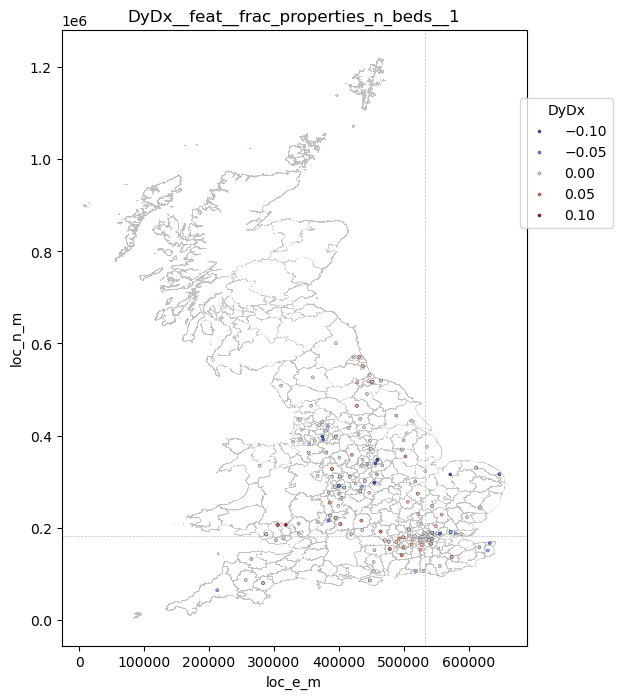

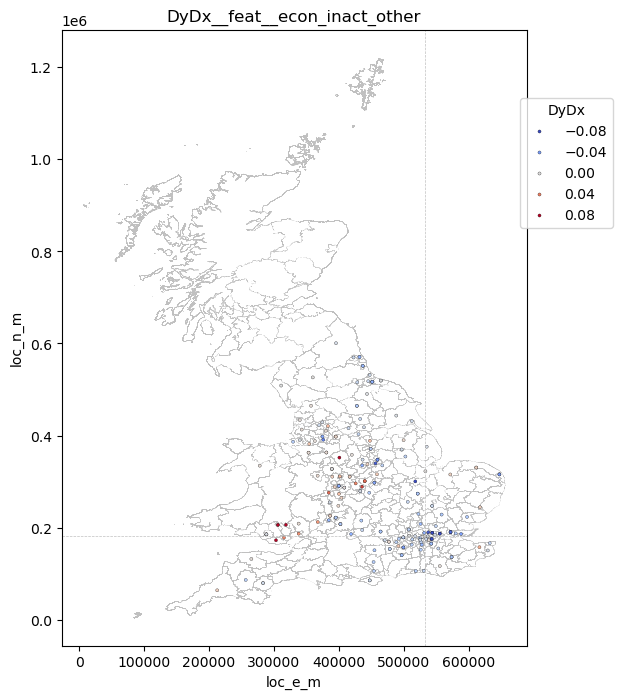

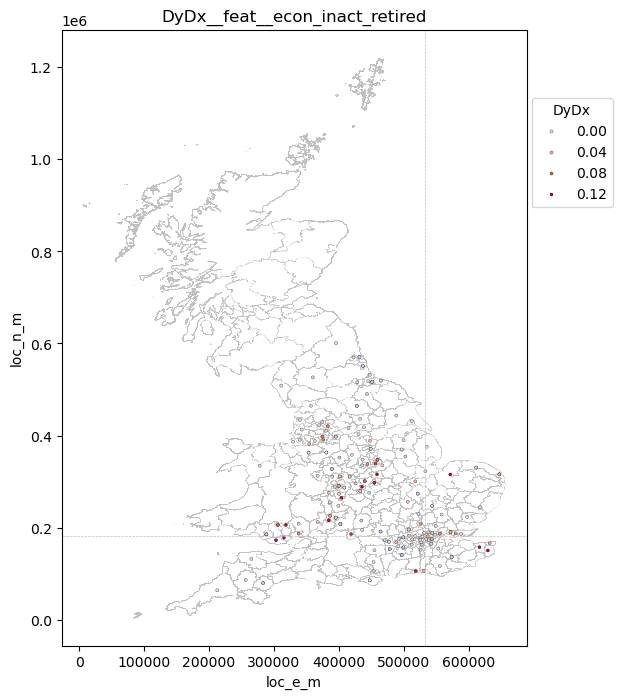

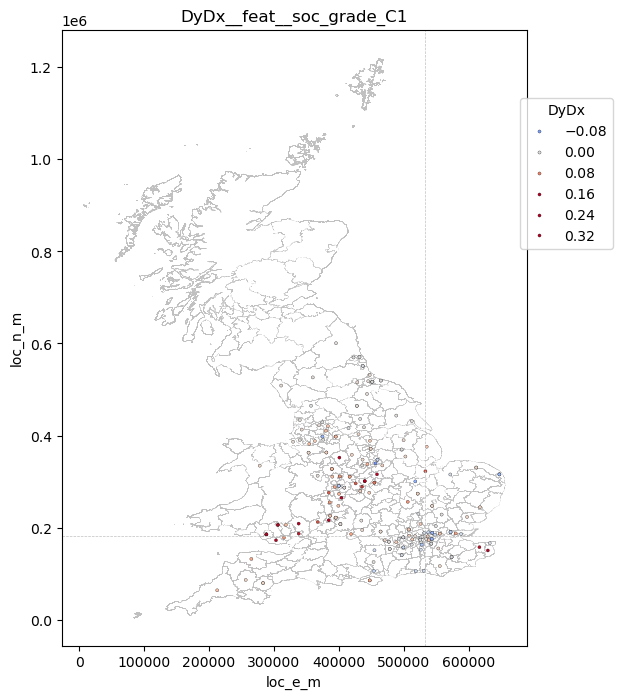

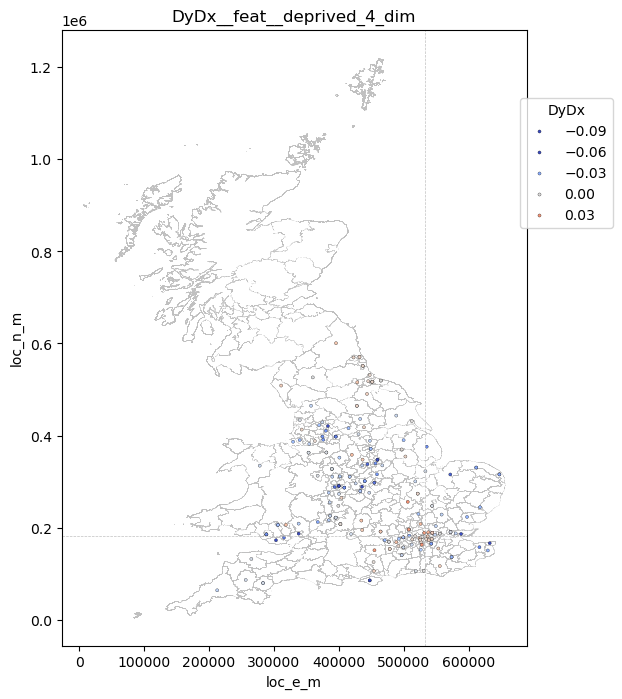

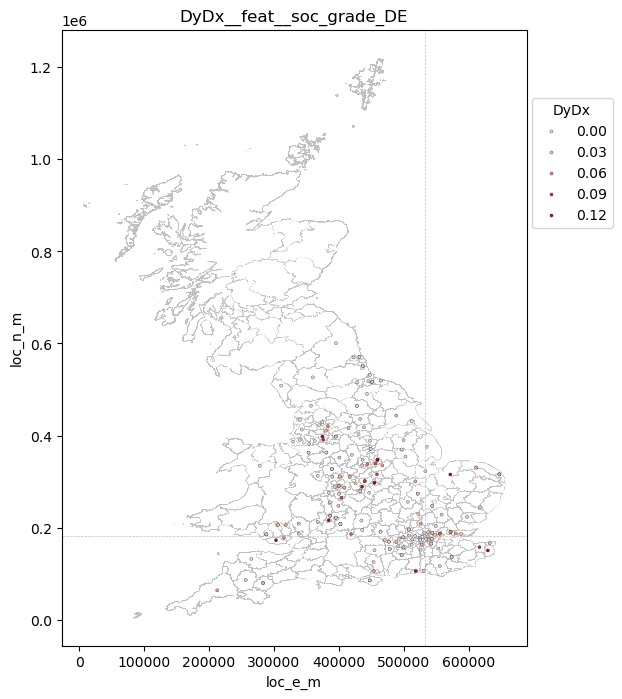

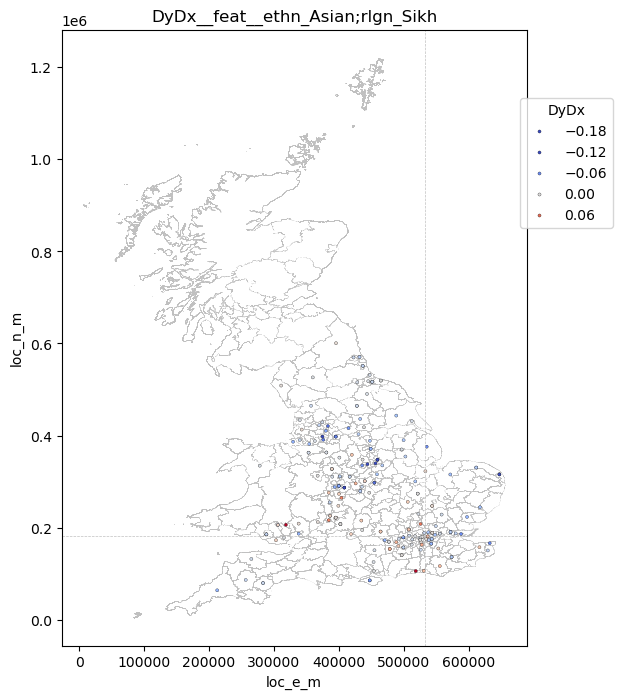

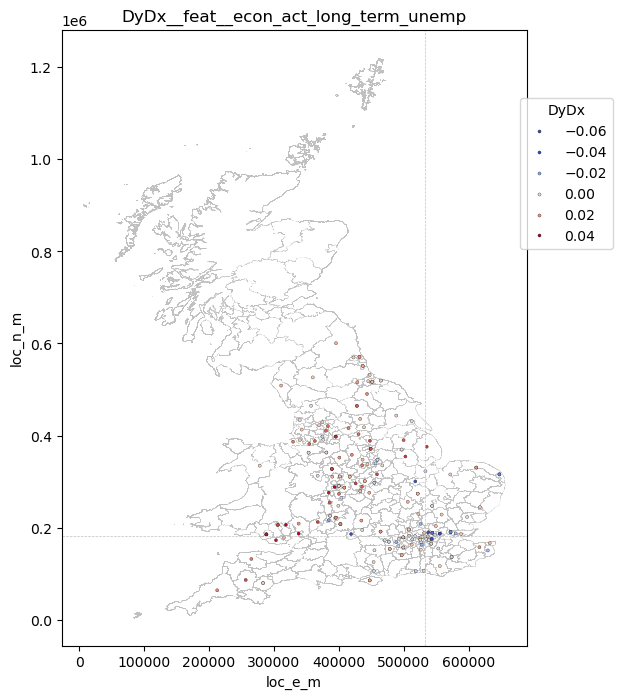

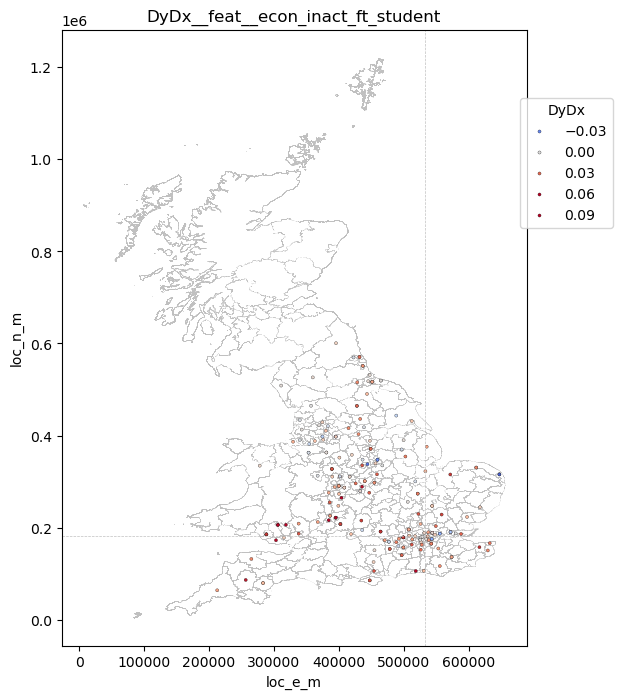

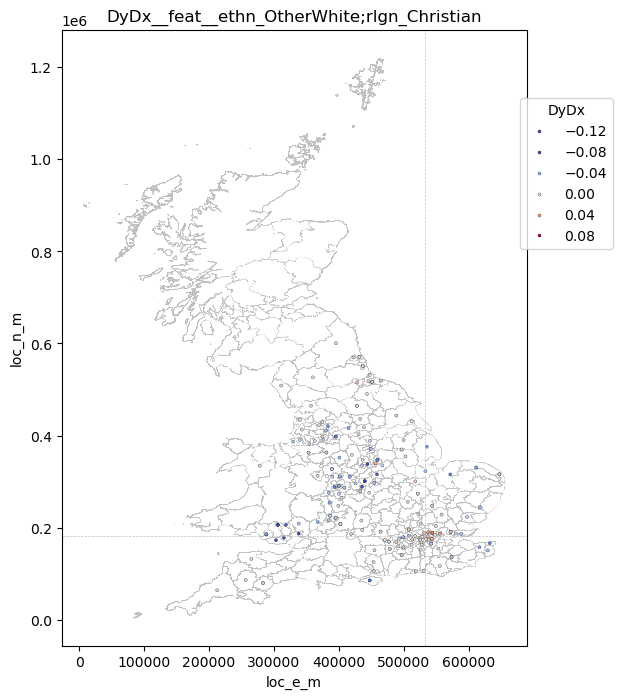

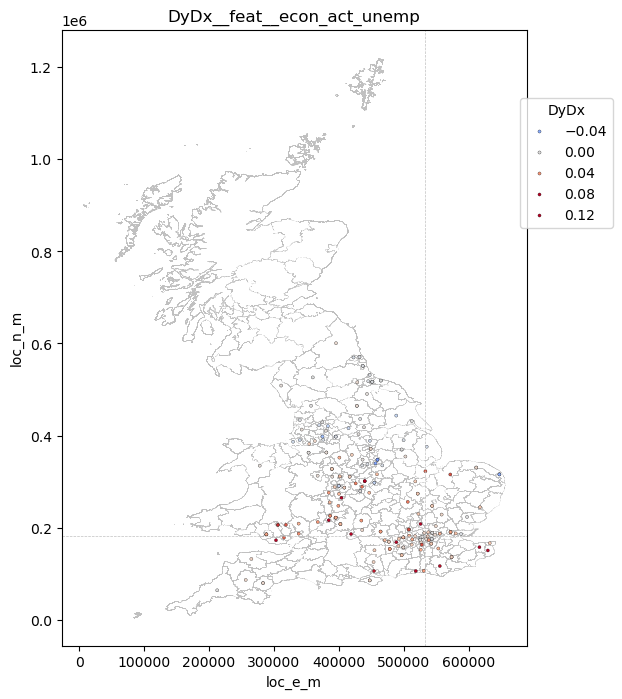

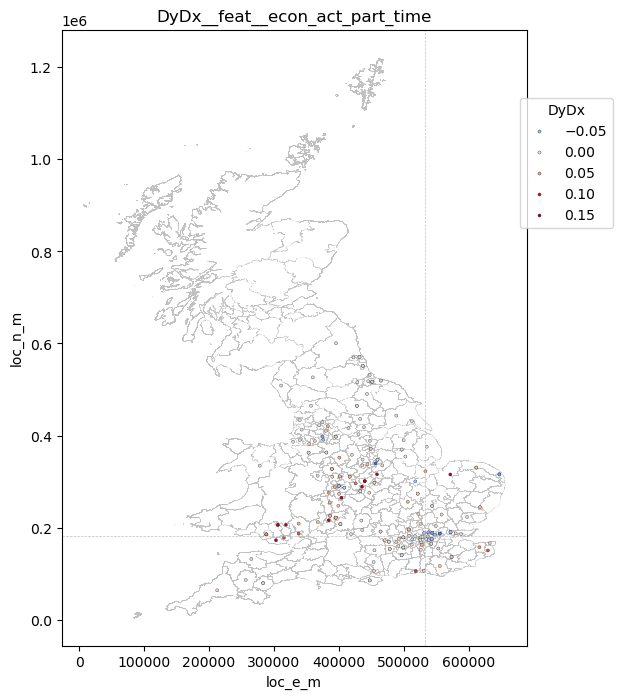

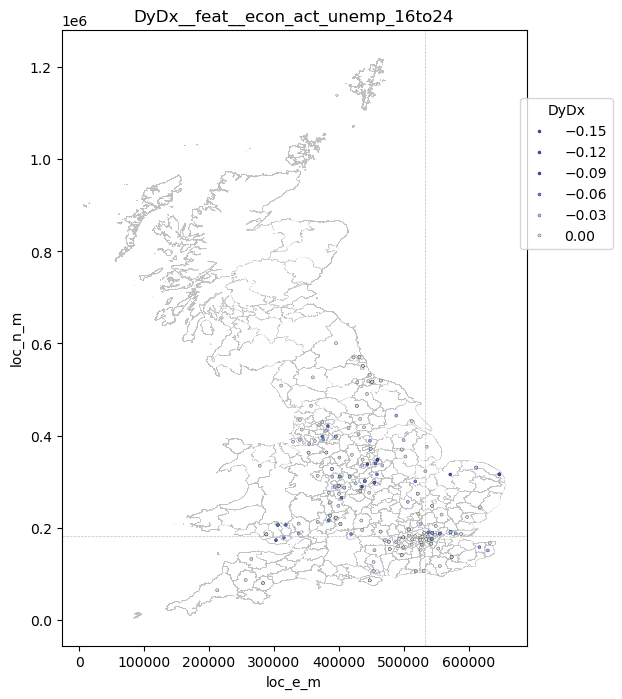

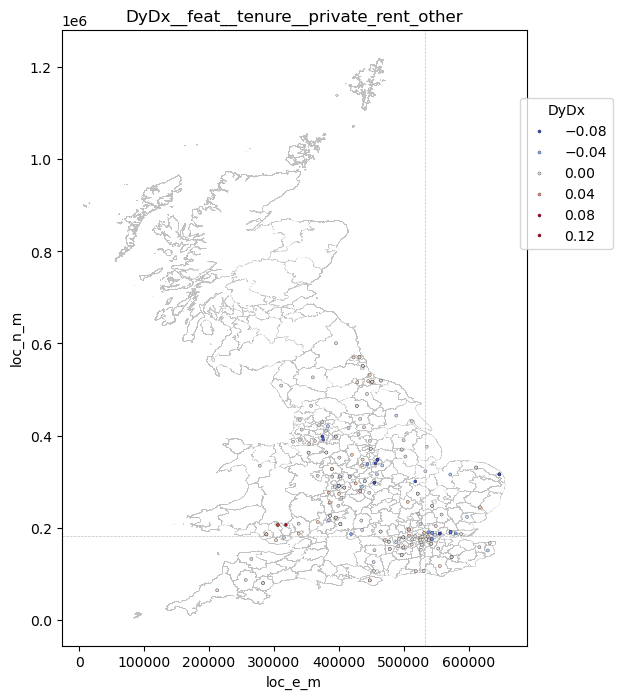

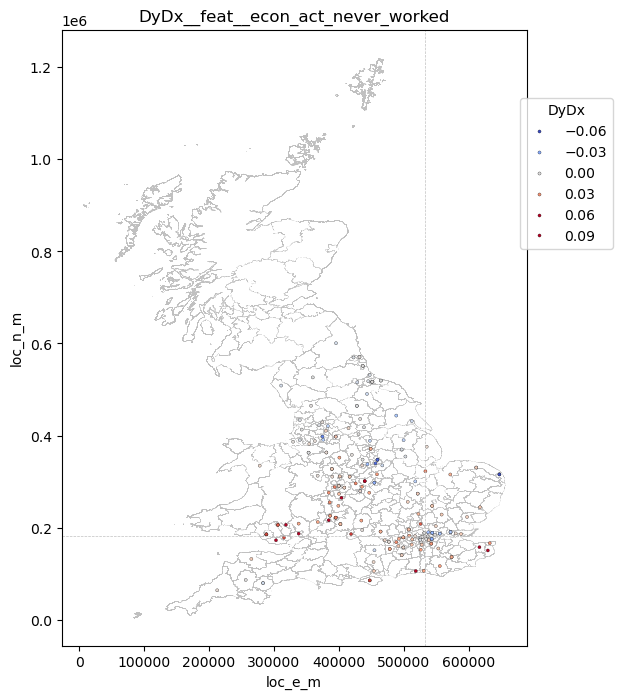

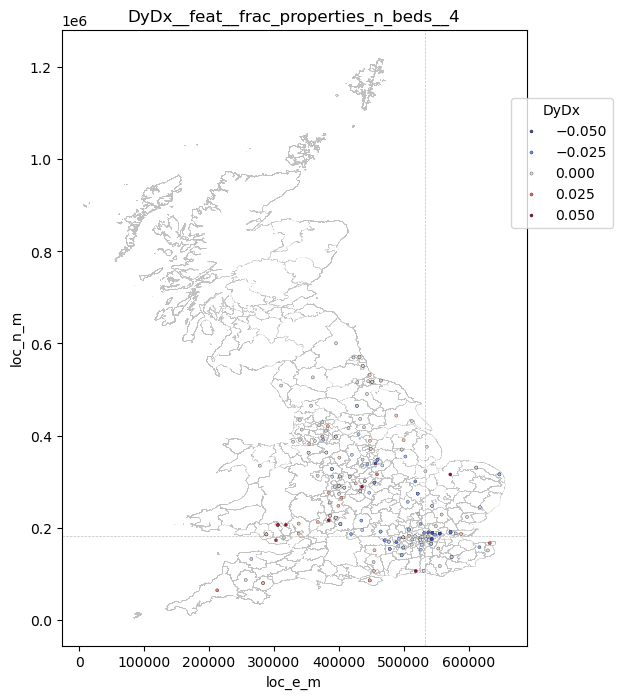

In [24]:
df_to_plot = df_DyDx_test_sub.copy()

for col in cols:
    hue_max_abs = df_DyDx_test_sub[col].abs().values.flatten()
    hue_max_abs = hue_max_abs[~np.isnan(hue_max_abs)]
    hue_max_abs = np.percentile(hue_max_abs, 95)

    fig, ax = plt.subplots(1,1, figsize=(6, 8))
    plot_map_on_ax(ax,sf, s=0.05)

    sns.scatterplot(
        data=df_to_plot,
        x='loc_e_m',
        y='loc_n_m',
        hue=col,
        hue_norm=(-hue_max_abs, hue_max_abs),
        edgecolor='black',
        linewidth=0.2,
        palette='coolwarm',
        s=5
    )
    ax.legend(bbox_to_anchor=(1.2, 0.9), title='DyDx')
    ax.set(title=col)